In [1]:
import numpy as np
import pandas as pd
pd.options.display.max_columns = 100

idx = pd.IndexSlice

pd.set_option('display.float_format', lambda x: '%.2f' % x)

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import seaborn as sb

from geopy.distance import geodesic

from scipy import stats
from scipy.spatial.distance import pdist, squareform, cosine

import requests
from bs4 import BeautifulSoup

import networkx as nx

ModuleNotFoundError: No module named 'geopy'

In [2]:
top_cats = [
    'PERSONNEL COMPENSATION',
    'FRANKED MAIL',
    'TRAVEL',
    'RENT COMMUNICATION UTILITIES',
    'PRINTING AND REPRODUCTION',
    'OTHER SERVICES',
    'SUPPLIES AND MATERIALS',
    'EQUIPMENT'
]

## Load data

### Centers of population

In [3]:
# https://www.census.gov/library/reference/code-lists/ansi.html#state
state_codes_df = pd.read_csv(
    'https://www2.census.gov/geo/docs/reference/state.txt',
    sep='|',
    dtype={'STATE':str}
)

# https://www.census.gov/geographies/reference-files/time-series/geo/centers-population.html
cop_df = pd.read_csv(
    'https://www2.census.gov/geo/docs/reference/cenpop2020/CenPop2020_Mean_ST.txt',
    dtype={'STATEFP':str}
)

cop_df = pd.merge(
    left = cop_df,
    right = state_codes_df,
    left_on = 'STATEFP',
    right_on = 'STATE',
    how = 'outer'
)

cop_df.loc[[52,53,54,55,56],'STATEFP'] = ['60','66','69','74','78']
cop_df.loc[[52,53,54,55,56],'LATITUDE'] = [14.3,13.4,16.4,np.nan,18.2]
cop_df.loc[[52,53,54,55,56],'LONGITUDE'] = [170.7,144.8,145.4,np.nan,-64.6]

cop_df.drop(55,inplace=True)

cop_df['DC_DIST'] = cop_df[['LATITUDE','LONGITUDE']].apply(lambda x: geodesic((x['LATITUDE'],x['LONGITUDE']),(cop_df.loc[8,'LATITUDE'],cop_df.loc[8,'LONGITUDE'])).km,axis=1)


cop_df = cop_df[['STATEFP','STUSAB','STATE_NAME','POPULATION','LATITUDE','LONGITUDE','DC_DIST']]
cop_df#.head()

NameError: name 'geodesic' is not defined

### Disbursements

In [4]:
all_db_df = pd.read_csv(
    'all_disbursements.csv',
    encoding='utf8',
    parse_dates=['DATE','START DATE','END DATE'],
    low_memory=False
)

all_db_df.head()

C:\Users\Brian\AppData\Local\Temp\ipykernel_31668\762952549.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_db_df = pd.read_csv(
C:\Users\Brian\AppData\Local\Temp\ipykernel_31668\762952549.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_db_df = pd.read_csv(


,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
0,2011Q1,NaN,OFFICE OF THE SPEAKER,Q1,PERSONNEL COMPENSATION,NaT,"CASSIDY, ED",2011-01-03,2011-03-31,DIRECTOR OF HOUSE OPERATIONS,41066.67,2011,NaN,NaN,"CASSIDY, ED",NaN,7
1,2011Q1,NaN,OFFICE OF THE SPEAKER,Q1,PERSONNEL COMPENSATION,NaT,"DALY, BRENDAN",2011-01-01,2011-01-02,COMMUNICATIONS DIRECTOR,958.33,2011,NaN,NaN,"DALY, BRENDAN",NaN,7
2,2011Q1,NaN,OFFICE OF THE SPEAKER,Q1,PERSONNEL COMPENSATION,NaT,"DALY, BRENDAN",2011-01-01,2011-01-02,COMMUNICATIONS DIRECTOR (OTHER COMPENSATION),13416.67,2011,NaN,NaN,"DALY, BRENDAN",NaN,7
3,2011Q1,NaN,OFFICE OF THE SPEAKER,Q1,PERSONNEL COMPENSATION,NaT,"ELSHAMI,NADEEM",2011-01-01,2011-01-02,DEPUTY COMMUNICATIONS DIRECTOR,943.73,2011,NaN,NaN,"ELSHAMI,NADEEM",NaN,7
4,2011Q1,NaN,OFFICE OF THE SPEAKER,Q1,PERSONNEL COMPENSATION,NaT,"GREEN, JO-MARIE S",2011-01-03,2011-03-31,GEN COUNSEL & CHIEF OF LEG OPS,42044.44,2011,NaN,NaN,"GREEN, JO-MARIE S",NaN,7


Filter to members' expenses.

In [5]:
members_df = all_db_df[all_db_df['BIOGUIDE_ID'].notnull()]
members_df['BIOGUIDE_ID'].value_counts()

BIOGUIDE_ID
H001053    14696
G000565    14115
J000292    13588
K000376    13503
C001063    13270
           ...  
M001120        3
C000090        2
A000014        2
S001153        1
W000314        1
Name: count, Length: 938, dtype: int64

### Bioguide data

In [6]:
legislators_df = pd.read_csv('https://theunitedstates.io/congress-legislators/legislators-historical.csv')
legislators_df.head()

,last_name,first_name,middle_name,suffix,nickname,full_name,birthday,gender,type,state,district,senate_class,party,url,address,phone,contact_form,rss_url,twitter,twitter_id,facebook,youtube,youtube_id,mastodon,bioguide_id,thomas_id,opensecrets_id,lis_id,fec_ids,cspan_id,govtrack_id,votesmart_id,ballotpedia_id,washington_post_id,icpsr_id,wikipedia_id
0,Bassett,Richard,NaN,NaN,NaN,NaN,1745-04-02,M,sen,DE,NaN,2.00,Anti-Administration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B000226,NaN,NaN,NaN,NaN,NaN,401222,NaN,NaN,NaN,507.00,Richard Bassett (Delaware politician)
1,Bland,Theodorick,NaN,NaN,NaN,NaN,1742-03-21,M,rep,VA,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B000546,NaN,NaN,NaN,NaN,NaN,401521,NaN,NaN,NaN,786.00,Theodorick Bland (congressman)
2,Burke,Aedanus,NaN,NaN,NaN,NaN,1743-06-16,M,rep,SC,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B001086,NaN,NaN,NaN,NaN,NaN,402032,NaN,NaN,NaN,1260.00,Aedanus Burke
3,Carroll,Daniel,NaN,NaN,NaN,NaN,1730-07-22,M,rep,MD,6.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C000187,NaN,NaN,NaN,NaN,NaN,402334,NaN,NaN,NaN,1538.00,Daniel Carroll
4,Clymer,George,NaN,NaN,NaN,NaN,1739-03-16,M,rep,PA,-1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C000538,NaN,NaN,NaN,NaN,NaN,402671,NaN,NaN,NaN,1859.00,George Clymer


In [7]:
legislators_df.tail()

,last_name,first_name,middle_name,suffix,nickname,full_name,birthday,gender,type,state,district,senate_class,party,url,address,phone,contact_form,rss_url,twitter,twitter_id,facebook,youtube,youtube_id,mastodon,bioguide_id,thomas_id,opensecrets_id,lis_id,fec_ids,cspan_id,govtrack_id,votesmart_id,ballotpedia_id,washington_post_id,icpsr_id,wikipedia_id
12131,Conway,Connie,NaN,NaN,NaN,Connie Conway,1950-09-25,F,rep,CA,22.00,NaN,Republican,NaN,1013 Longworth House Office Building Washingto...,202-225-2523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C001128,NaN,N00050064,NaN,H2CA22231,NaN,456866,81797.00,Connie Conway,NaN,NaN,Connie Conway
12132,Flores,Mayra,NaN,NaN,NaN,Mayra Flores,1986-01-01,F,rep,TX,34.00,NaN,Republican,NaN,307 Cannon House Office Building Washington DC...,202-225-9901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F000473,NaN,N00048049,NaN,H2TX34113,NaN,456867,NaN,Mayra Flores,NaN,NaN,Mayra Flores
12133,Sempolinski,Joseph,NaN,NaN,NaN,Joseph Sempolinski,1983-02-10,M,rep,NY,23.00,NaN,Republican,NaN,1203 Longworth House Office Building Washingto...,202-225-3161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S001219,NaN,N00048747,NaN,H2NY23137,NaN,456872,208849.00,Joe Sempolinski,NaN,NaN,Joe Sempolinski
12134,Inhofe,James,M.,NaN,Jim,James M. Inhofe,1934-11-17,M,sen,OK,NaN,2.00,Republican,https://www.inhofe.senate.gov,205 Russell Senate Office Building Washington ...,202-224-4721,https://www.inhofe.senate.gov/contact,http://www.inhofe.senate.gov/rss/feeds/?type=a...,NaN,NaN,NaN,NaN,NaN,NaN,I000024,583.00,N00005582,S236,"S4OK00083,H6OK01102",5619.00,300055,27027.00,Jim Inhofe,NaN,15424.00,Jim Inhofe
12135,Sasse,Benjamin,Eric,NaN,Ben,Ben Sasse,1972-02-22,M,sen,NE,NaN,2.00,Republican,https://www.sasse.senate.gov/public,139 Russell Senate Office Building Washington ...,202-224-4224,https://www.sasse.senate.gov/public/index.cfm/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S001197,2289.00,N00035544,S382,S4NE00090,77429.00,412671,150182.00,Ben Sasse,NaN,41503.00,Ben Sasse


### Pro-Publica

In [8]:
propublica_members_df = pd.read_csv('propublica_members.csv')
propublica_members_df.head()

,id,title,short_title,api_uri,first_name,middle_name,last_name,suffix,date_of_birth,gender,party,leadership_role,twitter_account,facebook_account,youtube_account,govtrack_id,cspan_id,votesmart_id,icpsr_id,crp_id,google_entity_id,fec_candidate_id,url,rss_url,contact_form,in_office,cook_pvi,dw_nominate,ideal_point,seniority,total_votes,missed_votes,total_present,last_updated,ocd_id,office,phone,fax,state,district,at_large,geoid,missed_votes_pct,votes_with_party_pct,votes_against_party_pct,next_election,congress
0,A000014,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Neil,NaN,Abercrombie,NaN,1938-06-26,M,D,NaN,neilabercrombie,NaN,hawaiirep1,400001.00,NaN,NaN,15244.00,NaN,/m/0255rj,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,22,1065.00,136.00,1.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:hi/cd:1,NaN,NaN,NaN,HI,1,False,1501,12.77,98.48,1.41,NaN,111
1,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,28,1655.00,132.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605,7.98,98.75,1.19,2010.00,111
2,A000055,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Robert,B.,Aderholt,NaN,1965-07-22,M,R,NaN,Robert_Aderholt,RobertAderholt,RobertAderholt,400004.00,45516.00,441.00,29701.00,N00003028,/m/024p03,NaN,https://aderholt.house.gov,https://aderholt.house.gov/rss.xml,NaN,False,NaN,NaN,NaN,14,1655.00,63.00,0.00,2021-03-02 02:35:23 -0500,ocd-division/country:us/state:al/cd:4,NaN,NaN,NaN,AL,4,False,104,3.81,93.37,6.56,2010.00,111
3,A000364,Representative,Rep.,https://api.propublica.org/congress/v1/members...,John,NaN,Adler,NaN,1959-08-23,M,D,NaN,NaN,NaN,NaN,412264.00,1030767.00,NaN,NaN,NaN,/m/05jzss,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,2,1655.00,34.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:nj/cd:3,NaN,NaN,NaN,NJ,3,False,3403,2.05,89.70,10.24,2010.00,111
4,A000358,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Todd,NaN,Akin,NaN,1947-07-05,M,R,NaN,reptoddakin,NaN,RepToddAkin,400005.00,87412.00,NaN,20123.00,NaN,/m/025xzm,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,10,1655.00,79.00,1.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:mo/cd:2,NaN,NaN,NaN,MO,2,False,2902,4.77,94.66,5.27,2010.00,111


In [256]:
bioguide_gender_party_map = propublica_members_df[['id','gender','party']].drop_duplicates(subset=['id']).set_index('id').to_dict('index')

member_names_map = propublica_members_df.copy()[['id','first_name','last_name']]
member_names_map['full_name'] = member_names_map['first_name'] + ' ' + member_names_map['last_name']
member_names_map = member_names_map.drop_duplicates(subset=['id']).set_index('id')['full_name'].to_dict()

### Member data

In [10]:
responses_d = {}

for _year in range(2015,2024):
    _request_str = 'http://archive.org/wayback/available?url=https://clerk.house.gov/xml/lists/MemberData.xml&timestamp={0}0201'.format(_year)
    responses_d[_year] = requests.get(_request_str).json()
    
responses_d

{2015: {'url': 'https://clerk.house.gov/xml/lists/MemberData.xml',
  'archived_snapshots': {'closest': {'status': '200',
    'available': True,
    'url': 'http://web.archive.org/web/20150601133900/http://clerk.house.gov/xml/lists/MemberData.xml',
    'timestamp': '20150601133900'}},
  'timestamp': '20150201'},
 2016: {'url': 'https://clerk.house.gov/xml/lists/MemberData.xml',
  'archived_snapshots': {'closest': {'status': '200',
    'available': True,
    'url': 'http://web.archive.org/web/20160305172335/http://clerk.house.gov:80/xml/lists/MemberData.xml',
    'timestamp': '20160305172335'}},
  'timestamp': '20160201'},
 2017: {'url': 'https://clerk.house.gov/xml/lists/MemberData.xml',
  'archived_snapshots': {'closest': {'status': '200',
    'available': True,
    'url': 'http://web.archive.org/web/20170126204415/http://clerk.house.gov/xml/lists/MemberData.xml',
    'timestamp': '20170126204415'}},
  'timestamp': '20170201'},
 2018: {'url': 'https://clerk.house.gov/xml/lists/MemberDa

In [11]:
# Container
content_dfs = {}

# String for retrieving content
content_string = 'https://web.archive.org/web/{0}if_/https://clerk.house.gov/xml/lists/MemberData.xml'

# Loop through each year
for _year, _response in responses_d.items():
    
    # Pull timestamp
    _timestamp = _response['archived_snapshots']['closest']['timestamp']
    
    # Retrieve content
    _content = requests.get(content_string.format(_timestamp)).text
    
    try:
        # Parse XML into a DataFrame
        _df = pd.read_xml(_content,xpath='./members/*/member-info',parser='lxml')
    
        # Extract Congress number
        _df['congress-num'] =  BeautifulSoup(_content).find_all('congress-num')[0].text
    
        content_dfs[_year] = _df
        
    except:
        print(_year)
        pass
    
member_data_df = pd.concat(content_dfs,names=['year']).reset_index(0)

member_data_df.to_csv('member_data_2015_2023.csv',index=False,encoding='utf8')

C:\ProgramData\Miniconda3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  warnings.warn(
C:\ProgramData\Miniconda3\lib\site-packages\bs4\builder\__init__.py:545: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup co

In [630]:
member_data_df = pd.read_csv('member_data_2015_2023.csv',encoding='utf8')

Extract the office information.

In [12]:
member_office_df = member_data_df.copy()[['year','bioguideID','office-building','office-room']]

member_office_df['office-floor'] = np.nan

_chob = member_office_df['office-building'] == 'CHOB'
member_office_df.loc[_chob,'office-floor'] = 'CHOB-' + member_office_df.loc[_chob,'office-room'].astype(str).str.get(0)

_lhob = member_office_df['office-building'] == 'LHOB'
member_office_df.loc[_lhob,'office-floor'] = 'LHOB-' + member_office_df.loc[_lhob,'office-room'].astype(str).str.get(1)

_rhob = member_office_df['office-building'] == 'RHOB'
member_office_df.loc[_rhob,'office-floor'] = 'RHOB-' + member_office_df.loc[_rhob,'office-room'].astype(str).str.get(1)

member_office_df.head()


,year,bioguideID,office-building,office-room,office-floor
0,2015,Y000033,RHOB,2314,RHOB-3
1,2015,B001289,CHOB,119,CHOB-1
2,2015,R000591,CHOB,442,CHOB-4
3,2015,R000575,CHOB,324,CHOB-3
4,2015,A000055,CHOB,235,CHOB-2


### Join

In [13]:
members_bioguide_df = pd.merge(
    left = members_df,
    right = propublica_members_df,
    left_on = 'BIOGUIDE_ID',
    right_on = 'id',
    how = 'left'
)

members_bioguide_df.head()

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER,id,title,short_title,api_uri,first_name,middle_name,last_name,suffix,date_of_birth,gender,party,leadership_role,twitter_account,facebook_account,youtube_account,govtrack_id,cspan_id,votesmart_id,icpsr_id,crp_id,google_entity_id,fec_candidate_id,url,rss_url,contact_form,in_office,cook_pvi,dw_nominate,ideal_point,seniority,total_votes,missed_votes,total_present,last_updated,ocd_id,office,phone,fax,state,district,at_large,geoid,missed_votes_pct,votes_with_party_pct,votes_against_party_pct,next_election,congress
0,2011Q1,A000014,HON. NEIL ABERCROMBIE,Q1,PERSONNEL COMPENSATION,NaT,"WESTFALL, ERIN K",2009-09-01,2009-09-30,RESEARCH AND MEDIA ASSISTANT,-16.67,2011,NaN,NaN,"WESTFALL, ERIN K",NaN,7,A000014,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Neil,NaN,Abercrombie,NaN,1938-06-26,M,D,NaN,neilabercrombie,NaN,hawaiirep1,400001.00,NaN,NaN,15244.00,NaN,/m/0255rj,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,22.00,1065.00,136.00,1.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:hi/cd:1,NaN,NaN,NaN,HI,1,False,1501.00,12.77,98.48,1.41,NaN,111.00
1,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,FRANKED MAIL,2011-02-22,UNITED STATES POSTAL SERVICE,2011-01-03,2011-01-31,FRANKED MAIL,183.23,2011,AP,00100926,UNITED STATES POSTAL SERVICE,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,28.00,1655.00,132.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,7.98,98.75,1.19,2010.00,111.00
2,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,FRANKED MAIL,2011-02-22,UNITED STATES POSTAL SERVICE,2011-01-03,2011-01-31,FRANKED MAIL,183.23,2011,AP,00100926,UNITED STATES POSTAL SERVICE,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,30.00,1607.00,143.00,3.00,2019-10-07 10:38:31 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,8.90,94.65,5.28,2012.00,112.00
3,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,FRANKED MAIL,2011-03-28,UNITED STATES POSTAL SERVICE,2011-02-01,2011-02-28,FRANKED MAIL,157.75,2011,AP,00127739,UNITED STATES POSTAL SERVICE,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,28.00,1655.00,132.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,7.98,98.75,1.19,2010.00,111.00
4,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,FRANKED MAIL,2011-03-28,UNITED STATES POSTAL SERVICE,2011-02-01,2011-02-28,FRANKED MAIL,157.75,2011,AP,00127739,UNITED STATES POSTAL SERVICE,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,30.00,1607.00,143.00,3.00,2019-10-07 10:38:31 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,8.90,94.65,5.28,2012.00,112.00


## Continuous anomalies

### Outliers

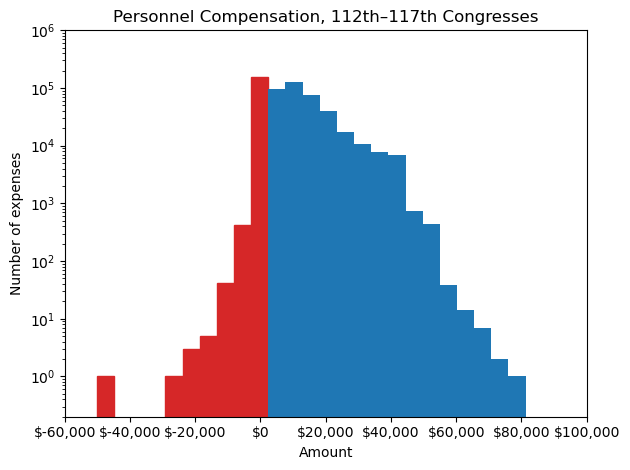

In [14]:
_s = members_df.loc[members_df['CATEGORY'] == 'PERSONNEL COMPENSATION','AMOUNT']
counts,bins = np.histogram(_s,bins=25)

f,ax = plt.subplots()
ax.hist(bins[:-1],bins,weights=counts)
ax.set_yscale('log')
ax.set_xlim((-60000,100000))
ax.set_ylim((2e-1,1e6))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('Amount')
ax.set_ylabel('Number of expenses')
ax.set_title('Personnel Compensation, 112th–117th Congresses')

for _i,_bin in enumerate(bins):
    if _bin < 0:
        ax.patches[_i].set_color('tab:red')
        
f.tight_layout()
f.savefig('personnel_compensation.png',dpi=300,bbox_inches='tight')

In [15]:
len(_s[_s > 50000]), len(_s[_s > 50000]) / len(_s)

(384, 0.0007139311391105979)

In [16]:
c0 = members_df['CATEGORY'] == 'PERSONNEL COMPENSATION'
c1 = members_df['AMOUNT'] > 50000
members_df.loc[c0 & c1,:].sort_values('AMOUNT',ascending=False)

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
4748125,2022Q4,M001166,2022 HON. JERRY MCNERNEY,Q4,PERSONNEL COMPENSATION,NaT,PROST GARY E,2022-03-01,2022-12-31,SR DISTRICT REPRESENTATIVE/ADV,81250.00,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4767563,2022Q4,S001199,2022 HON. LLOYD SMUCKER,Q4,PERSONNEL COMPENSATION,NaT,BONNER KATHERINE J.,2022-01-03,2022-12-31,CHIEF OF STAFF,71733.32,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4757860,2022Q4,P000610,2022 HON. STACEY E. PLASKETT,Q4,PERSONNEL COMPENSATION,NaT,JABBAR ANGELINE M,2022-06-01,2022-11-30,CHIEF OF STAFF,71083.29,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4708705,2022Q4,C001084,2022 HON. DAVID N. CICILLINE,Q4,PERSONNEL COMPENSATION,NaT,BIZZACCO CHRISTOPHER J,2022-06-01,2022-12-31,DISTRICT DIRECTOR,67416.63,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4774632,2022Q4,V000134,2022 HON. BETH VAN DUYNE,Q4,PERSONNEL COMPENSATION,NaT,OLSON JACOB N,2022-06-01,2022-12-31,CHIEF OF STAFF,67158.32,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4773211,2022Q4,T000486,2022 HON. RITCHIE TORRES,Q4,PERSONNEL COMPENSATION,NaT,POLLOCK SOPHIE D.,2022-10-01,2022-12-31,DEPUTY CHIEF OF STAFF,50000.01,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4731484,2022Q4,H000874,2022 HON. STENY H. HOYER,Q4,PERSONNEL COMPENSATION,NaT,CAREY STEFANIE,2022-10-01,2022-12-31,DEPUTY DISTRICT DIRECTOR,50000.01,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4766754,2022Q4,S000510,2022 HON. ADAM SMITH,Q4,PERSONNEL COMPENSATION,NaT,SERVIN SARAH L,2022-10-01,2022-12-31,CHIEF OF STAFF,50000.01,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
2756136,2017Q4,S001199,2017 HON. LLOYD SMUCKER,Q4,PERSONNEL COMPENSATION,NaT,FACCHIANO GREGORY,2017-06-01,2017-12-31,CHIEF OF STAFF,50000.01,2017,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2


In [17]:
c2 = members_df['PAYEE'] == 'VERGHESE MATTHEW M'
members_df.loc[c0 & c1 & c2,:]

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
4256663,2021Q4,B001304,2021 HON. ANTHONY G. BROWN,Q4,PERSONNEL COMPENSATION,NaT,VERGHESE MATTHEW M,2021-09-01,2021-12-31,CHIEF OF STAFF,53000.00,2021,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
4471014,2022Q2,B001304,2022 HON. ANTHONY G. BROWN,Q2,PERSONNEL COMPENSATION,NaT,VERGHESE MATTHEW M,2022-03-01,2022-06-30,CHIEF OF STAFF,51833.32,2022,,,NaN,OFFICIAL EXPENSES OF MEMBERS,4
4583111,2022Q3,B001304,2022 HON. ANTHONY G. BROWN,Q3,PERSONNEL COMPENSATION,NaT,VERGHESE MATTHEW M,2022-07-01,2022-09-30,CHIEF OF STAFF,50750.01,2022,,,NaN,OFFICIAL EXPENSES OF MEMBERS,5
4702469,2022Q4,B001304,2022 HON. ANTHONY G. BROWN,Q4,PERSONNEL COMPENSATION,NaT,VERGHESE MATTHEW M,2022-10-01,2022-12-31,CHIEF OF STAFF,50750.01,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6


### Ending in even digits

HC: Both before and after the decimal

In [18]:
amounts = members_bioguide_df['AMOUNT'].dropna().apply(np.abs).map('{:.2f}'.format).astype(str)

two_digits_before = amounts.str.split('.').apply(lambda x:str(int(x[0][-2:])))
two_digits_after = amounts.str.split('.').apply(lambda x:x[1])

In [19]:
two_digits_before_counts = two_digits_before.value_counts()
two_digits_after_counts = two_digits_after.value_counts()

two_digits_before_counts.index = ["{0:02d}".format(int(i)) for i in two_digits_before_counts.index]
two_digits_after_counts.index = ["{0:02d}".format(int(i)) for i in two_digits_after_counts.index]

# last_two_digits_counts = last_two_digits_counts[last_two_digits_counts.index.astype(int) >= 0]

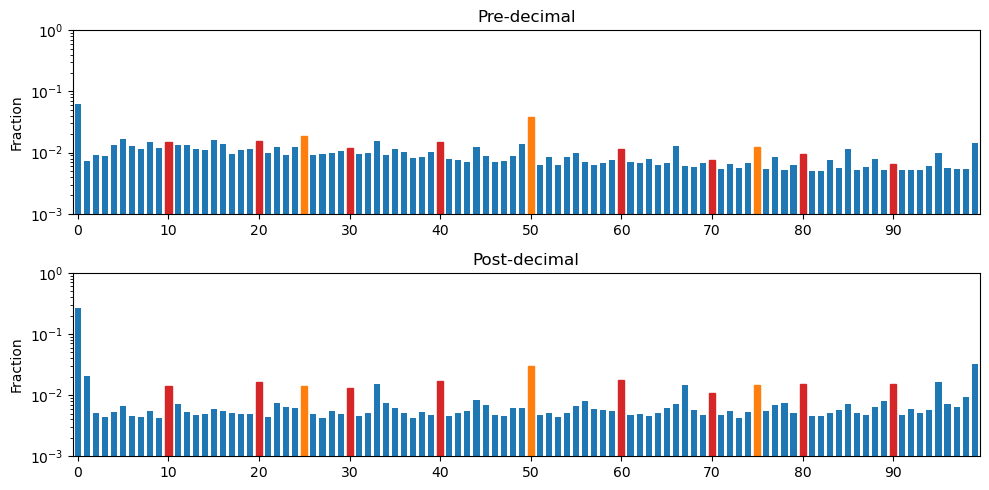

In [20]:
f,axs = plt.subplots(2,1,figsize=(10,5),subplot_kw={'yscale':'log','ylim':(1e-3,1e0),'ylabel':'Fraction'})

before_frac = two_digits_before_counts / two_digits_before_counts.sum()
after_frac = two_digits_after_counts / two_digits_after_counts.sum()

before_frac.sort_index().plot(width=.67, kind='bar',ax=axs[0])
after_frac.sort_index().plot(width=.67, kind='bar',ax=axs[1])

# axs[0].xaxis.set_major_locator(plt.MaxNLocator(90))
axs[0].set_xticks(range(0,100,10),range(0,100,10),rotation=0)
axs[1].set_xticks(range(0,100,10),range(0,100,10),rotation=0)

axs[0].set_title('Pre-decimal')
axs[1].set_title('Post-decimal')

axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

for _i in range(0,100,10):
    if _i > 0:
        axs[0].patches[_i].set_color('tab:red')
        axs[1].patches[_i].set_color('tab:red')
    
for _i in range(0,100,25):
    if _i > 0:
        axs[0].patches[_i].set_color('tab:orange')
        axs[1].patches[_i].set_color('tab:orange')

f.tight_layout()
f.savefig('pre_post_decimal.png',dpi=300,bbox_inches='tight')

In [21]:
two_digits_before_counts

00    1245204
50     779220
25     373963
05     334925
15     324528
       ...   
78     105893
86     104666
91     104330
81     102269
82     102051
Name: count, Length: 100, dtype: int64

### Benford's law

In [22]:
benfords_d = {}

for i in range(1,10):
    benfords_d[str(i)] = np.log10(1+(1/i))
    
benfords_s = pd.Series(benfords_d)
benfords_s

1   0.30
2   0.18
3   0.12
4   0.10
5   0.08
6   0.07
7   0.06
8   0.05
9   0.05
dtype: float64

In [23]:
def leading_digits_count(s):
    if type(s) == pd.Series:
        _gt0 = s[s > 0]
        _str = _gt0.astype(str)
        _leading = _str.str.get(0)
        _not0 = _leading[_leading != '0']
        
        return _not0.value_counts().sort_index()

#### Aggregate

In [24]:
leading_digit_dist_by_cat = {}

for _cat in members_df['CATEGORY'].value_counts().iloc[:-3].index:
    _amount = members_df.loc[members_df['CATEGORY'] == _cat,'AMOUNT']
    leading_digit_dist_by_cat[_cat] = leading_digits_count(_amount)
#     leading_digit_dist_by_cat[_cat] = _leading_digits / _leading_digits.sum()

leading_digit_dist_by_cat_df = pd.DataFrame(leading_digit_dist_by_cat)

leading_digit_dist_by_cat_df

,TRAVEL,RENT COMMUNICATION UTILITIES,SUPPLIES AND MATERIALS,PERSONNEL COMPENSATION,OTHER SERVICES,PRINTING AND REPRODUCTION,FRANKED MAIL,EQUIPMENT
AMOUNT,,,,,,,,
1,286293,290642,202335,210391,94810,42932,23916,32674
2,191485,131491,121782,98304,30281,29808,14422,24521
3,133931,111496,92613,57153,28670,23645,9538,16260
4,97771,114079,71606,35941,10649,17659,6969,10039
5,77942,86635,55878,25789,12051,14509,5412,7719
6,61603,65639,47341,21541,5855,12323,4437,4646
7,49147,51084,37181,23408,7339,10911,3925,4095
8,44113,49203,32427,28740,3826,7639,3547,4397
9,38828,40484,30296,33928,4469,9308,3294,3364


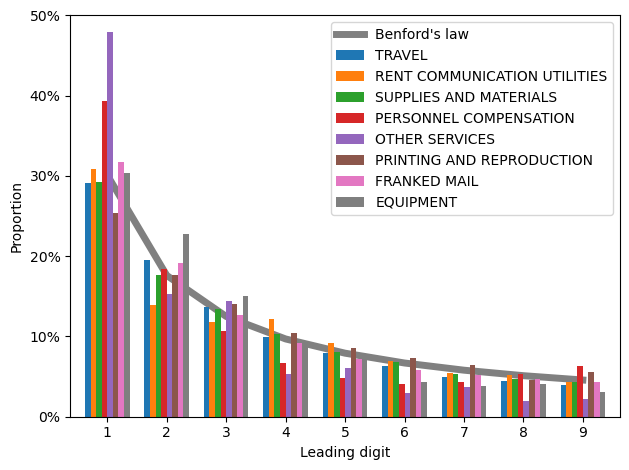

In [25]:
leading_digit_dist_by_cat_norm_df = leading_digit_dist_by_cat_df / leading_digit_dist_by_cat_df.sum()

f,ax = plt.subplots()

leading_digit_dist_by_cat_norm_df.plot(kind='bar',width=.75,ax=ax)
benfords_s.plot(ax=ax,color='grey',label='Benford\'s law',lw=5,zorder=0)
ax.legend()
ax.set_xlabel('Leading digit')
ax.set_ylabel('Proportion')
ax.set_ylim((0,.5))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

f.tight_layout()
f.savefig('benford_all_cat.png',dpi=300,bbox_inches='tight')

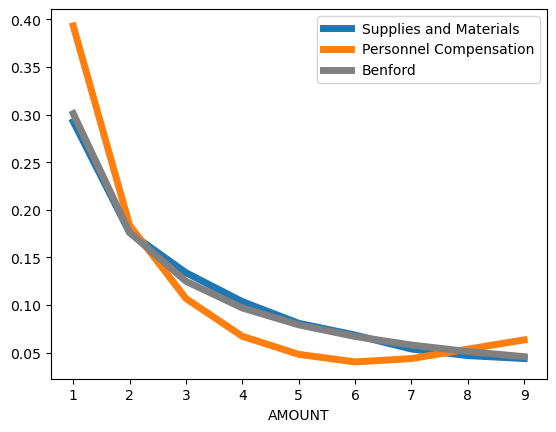

In [26]:
f,ax = plt.subplots()
leading_digit_dist_by_cat_norm_df['SUPPLIES AND MATERIALS'].plot(lw=5,label='Supplies and Materials',ax=ax)
leading_digit_dist_by_cat_norm_df['PERSONNEL COMPENSATION'].plot(lw=5,label='Personnel Compensation',ax=ax)
benfords_s.plot(ax=ax,lw=5,label='Benford',c='grey')
ax.legend()

In [27]:
dist_test_by_col = {}

for _col in leading_digit_dist_by_cat_df.columns:
    
    _col_vals = leading_digit_dist_by_cat_df.loc[:,_col]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    dist_test_by_col[_col] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_df = pd.DataFrame(dist_test_by_col).T
dist_test_df.sort_values('chi2_statistic',ascending=False)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
PERSONNEL COMPENSATION,0.22,0.99,39322.77,0.00
OTHER SERVICES,0.44,0.35,38546.60,0.00
RENT COMMUNICATION UTILITIES,0.11,1.00,15800.98,0.00
TRAVEL,0.22,0.99,6297.38,0.00
EQUIPMENT,0.44,0.35,4678.67,0.00
PRINTING AND REPRODUCTION,0.11,1.00,2395.30,0.00
SUPPLIES AND MATERIALS,0.11,1.00,1487.32,0.00
FRANKED MAIL,0.11,1.00,384.73,0.00


In [28]:
stats.zscore(leading_digit_dist_by_cat_df,axis=1)

,TRAVEL,RENT COMMUNICATION UTILITIES,SUPPLIES AND MATERIALS,PERSONNEL COMPENSATION,OTHER SERVICES,PRINTING AND REPRODUCTION,FRANKED MAIL,EQUIPMENT
AMOUNT,,,,,,,,
1,1.31,1.35,0.52,0.59,-0.50,-1.00,-1.18,-1.09
2,1.83,0.84,0.68,0.30,-0.82,-0.83,-1.08,-0.92
3,1.67,1.17,0.75,-0.05,-0.68,-0.80,-1.11,-0.96
4,1.30,1.70,0.65,-0.24,-0.87,-0.69,-0.96,-0.88
5,1.37,1.65,0.65,-0.32,-0.77,-0.69,-0.98,-0.91
6,1.38,1.54,0.79,-0.26,-0.90,-0.64,-0.96,-0.95
7,1.38,1.48,0.74,0.00,-0.86,-0.67,-1.04,-1.03
8,1.25,1.53,0.60,0.39,-1.00,-0.79,-1.01,-0.97
9,1.16,1.27,0.62,0.85,-1.02,-0.71,-1.09,-1.09


#### TODO: Break down bucket(s) by year

#### By representative

In [29]:
transaction_count = members_df['BIOGUIDE_ID'].value_counts()
members_gt1000_transactions = transaction_count[transaction_count >= 1000].index

In [30]:
leading_digit_dist_by_member = {}

for _member in members_gt1000_transactions:
    _amount = members_df.loc[members_df['BIOGUIDE_ID'] == _member,'AMOUNT']
    leading_digit_dist_by_member[_member] = leading_digits_count(_amount)
#     leading_digit_dist_by_member[_member] = _leading_digits / _leading_digits.sum()
    
leading_digit_dist_by_member_df = pd.DataFrame(leading_digit_dist_by_member)

leading_digit_dist_by_member_df

,H001053,G000565,J000292,K000376,C001063,P000601,T000193,S001172,S001185,C001051,G000546,L000491,M001157,J000032,W000809,H001058,D000600,L000566,B001270,P000597,F000449,S000522,D000616,L000551,K000009,F000459,A000055,D000615,S001177,M000087,S001148,C001061,K000362,C001053,B001248,D000191,C001087,W000791,S001150,S001195,G000551,C001080,M001165,F000450,G000552,W000800,S001192,W000795,T000460,G000553,...,Q000024,M001154,M001207,B000220,M001215,B001232,M000687,G000580,M001214,P000149,F000339,C001085,B001280,M001186,L000553,K000336,O000086,T000326,G000597,A000358,P000583,S001218,K000390,S000937,M001135,G000021,A000366,G000575,S000810,M001211,H001062,F000471,I000026,T000486,B001234,N000192,D000492,E000071,J000305,H001078,A000373,R000462,R000611,F000444,G000595,S001210,T000473,C001116,R000305,G000480
AMOUNT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4665,4398,3784,4174,4255,3766,4095,3994,3880,3681,3451,3790,3824,3686,3446,3218,3108,3549,3190,3538,2862,2757,3128,3370,3248,2920,3519,2729,3204,2710,3246,3013,2947,3194,2634,3155,2999,2789,3141,3475,2719,2998,3039,3186,2462,2956,2969,2774,3533,2881,...,369,412,402,318,432,360,359,459,473,356,346,378,361,447,374,318,350,390,395,328,342,391,363,315,323,305,394,323,321,341,328,372,321,371,336,393,310,357,347,376,325,267,319,270,308,300,294,331,330,315
2,2613,2560,2267,2264,2232,1901,2137,1919,2167,2039,1885,1999,1921,1929,2202,1849,2339,1792,1800,2138,1777,2259,1601,1669,1801,1855,1591,1804,1692,1581,1740,1414,1728,1691,1800,1842,1516,1735,1441,1417,1665,1606,1387,1622,1854,1885,1484,1633,1525,1354,...,193,175,177,251,205,208,199,200,217,277,207,206,197,186,163,267,222,152,177,218,179,200,190,218,190,178,176,186,160,199,202,222,154,193,138,169,146,191,168,190,162,173,146,184,215,215,141,185,169,158
3,1668,2108,2058,1687,1396,1896,1754,1317,1445,1444,1393,1437,1582,1318,1416,1395,1347,1547,1379,1193,1509,1548,1318,1328,1437,1273,1068,1187,1289,1217,1310,1207,1127,1268,1375,1364,1580,1129,1047,1190,1384,956,798,962,1101,1079,1385,1150,927,1101,...,155,206,169,173,148,106,170,129,123,149,168,131,193,127,160,191,164,88,123,159,159,159,135,173,177,127,121,172,79,112,147,145,99,117,129,125,117,149,135,98,184,91,169,118,102,137,116,131,122,201
4,1406,1162,1554,1381,1077,1191,1020,1294,1191,1100,1322,1369,1295,894,1127,1204,919,814,1142,923,1287,979,1185,811,1032,1071,1017,1008,773,1023,881,1019,951,1021,1386,850,915,992,923,801,989,859,781,885,1379,1054,1003,1043,777,1241,...,154,116,146,140,118,160,145,130,96,144,106,134,145,127,126,107,118,152,72,112,143,121,118,107,114,164,111,88,150,136,129,84,150,105,108,91,82,112,118,129,86,98,130,125,119,85,121,75,98,84
5,1068,1061,1065,990,993,826,863,816,967,1060,1253,747,973,905,798,908,737,924,1144,724,958,666,707,775,778,665,781,883,1028,869,805,886,862,573,763,559,702,880,776,718,737,654,1088,849,528,804,695,771,560,639,...,103,54,90,123,77,94,130,81,86,96,82,97,76,85,140,54,109,139,138,94,77,64,83,76,90,89,93,68,131,57,69,62,97,123,91,88,128,62,100,75,53,120,47,98,57,40,73,57,88,50
6,735,753,808,797,871,795,582,726,636,681,632,705,540,742,788,719,524,694,740,647,685,719,609,508,572,721,589,667,562,745,523,669,726,611,567,631,602,703,768,584,743,643,921,558,345,426,556,600,554,759,...,80,63,77,53,59,72,79,39,89,69,109,86,67,58,94,101,75,46,68,88,91,66,54,90,76,94,104,93,92,41,55,52,77,44,109,57,103,66,67,37,75,99,60,105,66,39,80,39,45,45
7,916,619,727,670,759,847,574,522,612,574,637,633,605,627,796,499,731,408,452,510,479,496,584,551,491,446,615,826,628,678,454,619,592,613,420,428,504,472,652,480,571,657,547,450,451,404,411,426,418,450,...,80,117,63,70,43,69,55,68,61,56,57,56,47,34,47,54,54,72,74,55,49,51,51,41,42,41,44,75,80,81,51,38,50,41,60,40,41,33,41,48,75,49,34,30,51,40,65,40,33,44
8,578,577,465,530,664,648,542,786,410,506,625,439,486,885,472,499,573,393,480,367,379,443,533,501,390,420,489,500,537,515,459,422,475,329,415,492,385,436,393,474,441,481,370,370,561,377,347,413,307,320,...,45

In [31]:
ks_test_by_member = {}
for _member in leading_digit_dist_by_member_df.columns:
    _col_vals = leading_digit_dist_by_member_df[_member]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    ks_test_by_member[_member] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_by_member_df = pd.DataFrame(ks_test_by_member).T
dist_test_by_member_df.sort_values('chi2_statistic',ascending=False).head(20)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
V000081,0.22,0.99,631.04,0.00
G000552,0.22,0.99,548.38,0.00
P000034,0.44,0.35,526.51,0.00
M001165,0.22,0.99,525.11,0.00
R000486,0.22,0.99,520.15,0.00
S001189,0.33,0.73,469.03,0.00
T000460,0.22,0.99,443.14,0.00
P000609,0.44,0.35,411.52,0.00
B001248,0.33,0.73,404.34,0.00
L000397,0.33,0.73,377.42,0.00


#### Member-level travel

In [32]:
leading_digit_dist_by_member_travel = {}

for _member in members_gt1000_transactions:
    _amount = members_df.loc[(members_df['BIOGUIDE_ID'] == _member) & (members_df['CATEGORY'] == 'TRAVEL'),'AMOUNT']
    leading_digit_dist_by_member_travel[_member] = leading_digits_count(_amount)
#     leading_digit_dist_by_member_travel[_member] = _leading_digits / _leading_digits.sum()
    
leading_digit_dist_by_member_travel_df = pd.DataFrame(leading_digit_dist_by_member_travel)

leading_digit_dist_by_member_travel_df

,H001053,G000565,J000292,K000376,C001063,P000601,T000193,S001172,S001185,C001051,G000546,L000491,M001157,J000032,W000809,H001058,D000600,L000566,B001270,P000597,F000449,S000522,D000616,L000551,K000009,F000459,A000055,D000615,S001177,M000087,S001148,C001061,K000362,C001053,B001248,D000191,C001087,W000791,S001150,S001195,G000551,C001080,M001165,F000450,G000552,W000800,S001192,W000795,T000460,G000553,...,Q000024,M001154,M001207,B000220,M001215,B001232,M000687,G000580,M001214,P000149,F000339,C001085,B001280,M001186,L000553,K000336,O000086,T000326,G000597,A000358,P000583,S001218,K000390,S000937,M001135,G000021,A000366,G000575,S000810,M001211,H001062,F000471,I000026,T000486,B001234,N000192,D000492,E000071,J000305,H001078,A000373,R000462,R000611,F000444,G000595,S001210,T000473,C001116,R000305,G000480
AMOUNT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1814,2123,1162,1009,843,690,754,1214,676,1228,1371,1568,1135,623,1131,1021,912,854,1063,1043,1042,559,874,600,883,790,726,811,881,854,691,621,901,771,614,913,1136,933,650,763,575,920,351,680,271,797,1162,752,705,525,...,65,91,70,66,150,73,8.00,54,138,46,60,95,64,111,35,92,60,53,86,74,49,113,116,40,54,57,51,75,37,108,89,91,70,92,32,98,36,49,59,114,61,26,32,43,58,107,66,124,37,92
2,1123,1384,787,760,666,473,521,685,692,791,773,1021,819,305,779,748,805,599,729,725,725,956,530,426,589,623,610,710,692,540,390,434,530,564,532,349,581,522,508,390,441,501,225,489,295,621,687,535,354,263,...,32,35,59,43,101,47,6.00,47,92,99,28,44,63,47,32,51,37,42,65,54,26,63,70,31,46,54,47,46,20,69,60,82,37,51,25,43,19,46,31,72,37,25,33,31,74,77,20,66,29,58
3,660,1306,721,535,366,318,421,481,481,645,556,657,597,325,462,563,512,430,578,532,566,414,479,296,442,402,401,505,423,406,315,275,424,375,336,253,433,460,350,355,405,375,168,292,162,451,540,255,266,212,...,32,24,35,41,76,28,6.00,32,40,73,24,26,40,64,50,28,62,21,36,24,15,66,43,12,49,22,26,29,17,51,52,68,24,36,7,19,10,73,36,33,26,14,25,15,23,27,28,29,25,31
4,553,616,653,387,282,254,253,399,291,377,588,473,393,157,287,372,554,247,415,420,298,375,378,288,245,318,349,459,282,296,247,244,405,288,628,248,281,284,248,209,244,252,215,337,339,288,440,173,180,335,...,31,37,73,32,49,22,61.00,26,27,22,16,22,31,29,14,22,54,15,10,24,15,36,23,13,30,16,15,24,21,45,33,27,17,28,3,27,10,35,19,21,15,7,16,14,29,23,30,26,13,24
5,365,590,459,329,278,233,181,312,308,360,558,371,361,128,229,328,365,132,358,238,241,145,252,322,199,218,219,441,252,233,370,175,320,216,180,183,226,254,211,163,241,195,144,189,101,212,408,237,129,162,...,14,19,22,28,47,24,17.00,14,21,14,13,5,19,26,32,14,54,12,39,19,26,29,30,11,33,15,20,13,9,15,22,21,14,50,3,39,45,12,20,24,10,3,12,18,19,11,16,14,16,18
6,277,404,285,195,186,176,139,353,166,265,319,295,226,183,264,287,269,129,306,169,172,102,211,143,214,227,226,295,203,192,182,189,252,188,149,194,207,189,268,94,173,177,116,136,56,88,235,155,116,139,...,16,13,14,10,31,17,2.00,6,23,13,10,17,13,21,5,16,31,9,24,11,17,29,17,16,11,14,13,17,4,15,14,7,12,22,3,24,29,25,27,11,10,7,10,17,35,10,13,5,9,20
7,256,304,236,185,149,199,136,176,121,194,232,232,151,164,159,224,279,88,187,130,176,100,190,138,113,113,198,313,110,163,131,136,162,137,115,172,176,161,132,112,148,142,79,172,63,94,187,111,98,124,...,12,9,13,14,29,19,1.00,19,11,5,6,17,12,12,1,16,21,13,22,15,5,23,23,10,10,11,7,10,8,30,14,7,12,4,28,9,6,4,20,9,12,7,7,8,17,12,9,6,5,23
8,204,255,199,181,127,169,96,270,80,214,244,172,148,80,161,201,210,141,179,151,120,104,142,126,95,120,120,175,163,188,184,97,145,99,134,139,127,201,133,100,102,144,73,75,76,117,196,99,58,94,...,16,21,5,9,36,17,NaN,4,9,3,6,9,32,7,5,10,17,7,10,13,6,9,22,3,8,3,2,15,15,10,14,12,8,12,7,12,3,12,18,8,9,3,5,8,14,14,27,6,4,14
9,270,230,168,144,86,129,67,207,123,158,189,290,123,98,98,146,98,109,114,122,114,91,134,117,66,85,90,146,119,143,87,118,157,95,93,164,104,180,105,122,71,120,66,90,32,81,181,80,95,107,...,14,8,7,10,21,16,3.00,6,6,8,2,14,6,8,6,11,20,16,18,13,9,17,17,7,10,7,7,11,6,13,18,36,5,

In [33]:
ks_test_by_member_travel = {}

for _member in leading_digit_dist_by_member_travel_df.columns:
    _col_vals = leading_digit_dist_by_member_travel_df.loc[:,_member]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    ks_test_by_member_travel[_member] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_by_member_travel_df = pd.DataFrame(ks_test_by_member_travel).T
dist_test_by_member_travel_df.sort_values('chi2_statistic',ascending=False).head(20)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
V000081,0.44,0.35,955.10,0.00
S000185,0.33,0.73,932.78,0.00
S000522,0.44,0.35,680.67,0.00
B001248,0.22,0.99,578.12,0.00
S001165,0.44,0.35,483.12,0.00
S000244,0.33,0.73,481.45,0.00
M001143,0.22,0.99,441.67,0.00
L000559,0.44,0.35,433.72,0.00
H000067,0.22,0.99,418.96,0.00
W000207,0.22,0.99,413.50,0.00


Inspect.

In [34]:
c0 = members_df['BIOGUIDE_ID'] == 'V000081'
c1 = members_df['CATEGORY'] == 'TRAVEL'

_df = members_df.copy().loc[c0 & c1,:]

_df['leading'] = _df['AMOUNT'].apply(np.abs).astype(str).str.get(0)

_df.head()

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER,leading
97626,2011Q1,V000081,HON. NYDIA M. VELAZQUEZ,Q1,TRAVEL,2011-02-18,CITIBANK GOV CARD SERVICE,2011-01-05,2011-01-05,COMMERCIAL TRANSPORTATION,62.70,2011,AP,00097608,CITIBANK GOV CARD SERVICE,NaN,7,6
97627,2011Q1,V000081,HON. NYDIA M. VELAZQUEZ,Q1,TRAVEL,2011-02-18,CITIBANK GOV CARD SERVICE,2011-01-07,2011-01-07,COMMERCIAL TRANSPORTATION,162.00,2011,AP,00097609,CITIBANK GOV CARD SERVICE,NaN,7,1
97628,2011Q1,V000081,HON. NYDIA M. VELAZQUEZ,Q1,TRAVEL,2011-02-18,CITIBANK GOV CARD SERVICE,2011-01-18,2011-01-18,COMMERCIAL TRANSPORTATION,167.00,2011,AP,00097610,CITIBANK GOV CARD SERVICE,NaN,7,1
97629,2011Q1,V000081,HON. NYDIA M. VELAZQUEZ,Q1,TRAVEL,2011-02-18,CITIBANK GOV CARD SERVICE,2011-01-22,2011-01-22,COMMERCIAL TRANSPORTATION,62.70,2011,AP,00097611,CITIBANK GOV CARD SERVICE,NaN,7,6
97630,2011Q1,V000081,HON. NYDIA M. VELAZQUEZ,Q1,TRAVEL,2011-02-18,CITIBANK GOV CARD SERVICE,2011-01-24,2011-01-24,COMMERCIAL TRANSPORTATION,62.70,2011,AP,00097612,CITIBANK GOV CARD SERVICE,NaN,7,6


In [35]:
_df['leading'].value_counts(normalize=True)

leading
6   0.29
1   0.23
5   0.15
2   0.10
3   0.10
9   0.03
4   0.03
7   0.03
8   0.03
0   0.00
Name: proportion, dtype: float64

In [36]:
_df.loc[_df['leading'] == '6','AMOUNT']

97626      62.70
97629      62.70
97630      62.70
97632      62.70
97633      62.70
           ...  
4667498    62.60
4667501   660.54
4775297    62.60
4775299    62.60
4775305    60.58
Name: AMOUNT, Length: 291, dtype: float64

Is there a difference between the median distribution of digits and Benford's law?

In [38]:
leading_digit_dist_by_member_travel_norm_df = leading_digit_dist_by_member_travel_df / leading_digit_dist_by_member_travel_df.sum()
top10_members_travel = leading_digit_dist_by_member_travel_norm_df.loc[:,dist_test_by_member_travel_df.sort_values('chi2_statistic',ascending=False).head(10).index]
bot10_members_travel = leading_digit_dist_by_member_travel_norm_df.loc[:,dist_test_by_member_travel_df.sort_values('chi2_statistic').head(10).index]

leading_digit_travel_median = leading_digit_dist_by_member_travel_df.median(1)
leading_digit_travel_median_norm = leading_digit_travel_median/leading_digit_travel_median.sum()

stats.chisquare(leading_digit_travel_median,leading_digit_travel_median.sum() * benfords_s)


Power_divergenceResult(statistic=9.360229051392377, pvalue=0.3128244668810841)

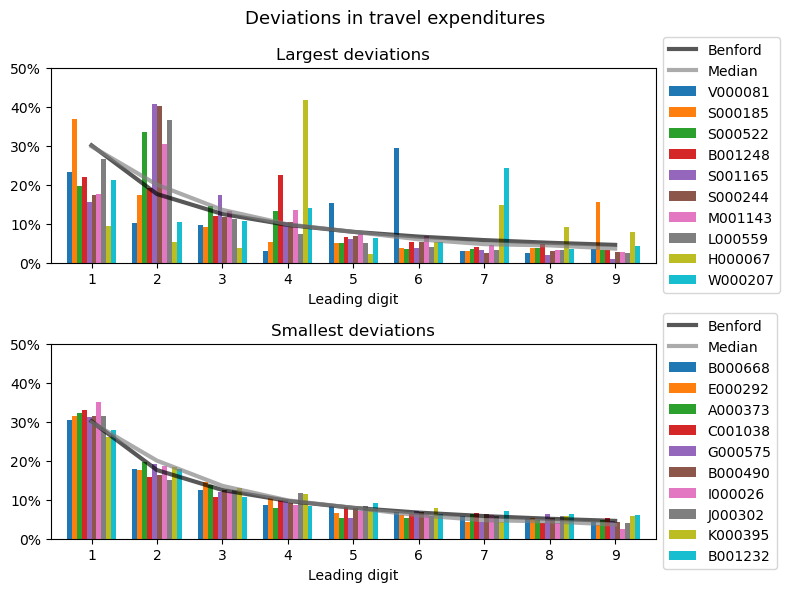

In [39]:
f,axs = plt.subplots(2,1,figsize=(8,6),sharey=True,subplot_kw={'ylim':(0,.5)})

top10_members_travel.plot(kind='bar',width=.75,ax=axs[0],legend=False)
axs[0].set_title('Largest deviations')

bot10_members_travel.plot(kind='bar',width=.75,ax=axs[1],legend=False)
axs[1].set_title('Smallest deviations')

for _ax in axs:
    _ax.plot(benfords_s,c='k',lw=3,alpha=.66,label='Benford')
    _ax.plot(leading_digit_travel_median_norm,c='grey',lw=3,alpha=.66,label='Median')
    _ax.legend(loc='center left',bbox_to_anchor=(1,.5))
    _ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    _ax.set_xticklabels(range(1,10), rotation = 0)
    _ax.set_xlabel('Leading digit')

f.suptitle('Deviations in travel expenditures',fontsize=13)

f.tight_layout()

f.savefig('benford_travel_top_bot_10.png',bbox_inches='tight')

#### Member-level personnel expenses

In [40]:
leading_digit_dist_by_member_personnel = {}

for _member in members_gt1000_transactions:
    _amount = members_df.loc[(members_df['BIOGUIDE_ID'] == _member) & (members_df['CATEGORY'] == 'PERSONNEL COMPENSATION'),'AMOUNT']
    leading_digit_dist_by_member_personnel[_member] = leading_digits_count(_amount)
#     leading_digit_dist_by_member_personnel[_member] = _leading_digits / _leading_digits.sum()
    
leading_digit_dist_by_member_personnel_df = pd.DataFrame(leading_digit_dist_by_member_personnel)

leading_digit_dist_by_member_personnel_df

,H001053,G000565,J000292,K000376,C001063,P000601,T000193,S001172,S001185,C001051,G000546,L000491,M001157,J000032,W000809,H001058,D000600,L000566,B001270,P000597,F000449,S000522,D000616,L000551,K000009,F000459,A000055,D000615,S001177,M000087,S001148,C001061,K000362,C001053,B001248,D000191,C001087,W000791,S001150,S001195,G000551,C001080,M001165,F000450,G000552,W000800,S001192,W000795,T000460,G000553,...,Q000024,M001154,M001207,B000220,M001215,B001232,M000687,G000580,M001214,P000149,F000339,C001085,B001280,M001186,L000553,K000336,O000086,T000326,G000597,A000358,P000583,S001218,K000390,S000937,M001135,G000021,A000366,G000575,S000810,M001211,H001062,F000471,I000026,T000486,B001234,N000192,D000492,E000071,J000305,H001078,A000373,R000462,R000611,F000444,G000595,S001210,T000473,C001116,R000305,G000480
AMOUNT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,619,410,429,666,443,534,498,494,540,607,472,421,493,331,557,408,485,445,413,691,455,444,398,630,520,461,520,449,490,518,456,618,435,605,469,476,586,365,729,446,471,486,645,562,464,544,417,422,619,406,...,50,112,84,57,46,70,82,84,76,73,103,86,78,62,74,104,75,90,79,55,88,79,67,74,86,52.00,68,46,61,67,57,58,56,61,103,73,89,45,81,59,81,92,76,85,85,54,48,57,100,59
2,178,193,177,314,167,178,248,225,196,260,164,204,228,199,211,220,182,176,212,285,249,241,112,212,159,203,222,274,206,253,241,281,174,223,291,261,242,235,282,133,250,235,247,226,254,222,259,212,303,208,...,29,41,45,27,36,28,53,24,36,30,58,46,46,51,44,55,41,47,28,39,43,61,37,55,43,28.00,30,29,15,39,19,22,33,51,32,51,31,31,50,16,33,44,25,59,38,28,21,49,59,29
3,133,117,109,147,80,136,137,126,105,130,92,133,142,133,132,113,85,138,147,117,126,128,91,119,95,94,100,123,101,106,107,212,81,135,97,147,93,89,139,87,143,160,112,104,99,87,142,66,141,146,...,18,21,22,20,20,17,26,15,12,26,26,13,15,24,16,16,22,16,22,31,24,17,18,21,46,27.00,10,23,17,15,25,4,20,25,21,19,20,15,36,7,26,24,24,17,9,24,11,17,27,28
4,77,85,64,116,79,73,48,76,63,106,118,90,94,68,59,137,28,62,121,55,62,85,71,54,69,48,96,66,51,99,62,118,53,32,103,54,68,91,80,54,83,71,66,65,105,112,63,94,74,117,...,5,14,12,6,5,20,17,13,19,24,23,16,19,15,10,11,7,7,15,13,25,18,12,12,10,21.00,10,13,15,12,15,20,18,20,14,12,12,12,12,11,12,19,23,9,22,16,12,13,7,10
5,35,76,48,66,71,62,51,33,43,106,84,35,68,56,35,50,32,24,86,34,69,100,24,85,35,49,66,70,92,85,37,61,64,38,57,38,45,33,33,27,43,42,49,80,67,41,70,62,72,58,...,10,10,10,10,7,8,18,13,3,20,21,9,14,14,13,8,5,7,17,13,9,9,5,12,16,7.00,9,10,5,14,12,10,4,21,13,13,6,10,16,3,4,9,12,11,6,5,4,2,14,5
6,21,50,88,68,77,53,80,28,33,86,32,37,53,59,22,58,36,20,41,35,63,127,28,50,39,20,34,44,36,101,52,58,53,31,27,56,17,35,27,46,55,61,48,66,44,28,42,63,49,34,...,7,11,10,6,8,16,11,2,6,11,8,11,7,6,11,3,12,3,11,13,13,9,7,11,16,14.00,11,14,11,5,5,10,8,4,11,8,7,2,10,10,19,11,4,9,5,3,8,5,12,4
7,69,85,75,61,133,57,36,44,27,61,69,14,58,55,30,73,55,29,50,22,61,69,34,59,55,65,35,66,46,54,38,52,39,22,46,53,18,46,36,38,40,34,55,61,56,72,26,62,38,61,...,5,9,12,15,4,1,3,7,7,12,7,12,7,4,14,13,7,2,4,7,5,4,12,11,12,NaN,17,16,24,4,9,8,12,9,7,2,4,2,7,9,11,14,4,1,4,7,15,4,5,8
8,72,79,72,87,151,87,87,86,54,97,84,57,62,83,63,102,81,49,58,38,61,82,54,85,45,68,39,63,29,81,51,90,48,28,85,90,66,70,47,45,58,71,30,86,79,74,42,109,53,56,...,10,14,10,10,4,3,9,9,7,9,15,9,14,1,23,11,2,11,4,4,12,6,14,14,10,4.00,9,22,11,4,17,8,37,13,23,7,22,1,6,6,11,22,20,4,7,7,10,5,5,10
9,69,85,80,115,106,81,122,67,110,83,84,89,79,92,90,95,85,47,45,56,99,66,81,97,57,89,37,73,54,131,40,82,72,69,41,89,48,46,55,69,67,64,46,84,132,70,48,105,53,51,...,11,8,14,22,8,15,9,11,7,10,16,27,16,14,5,7,1,3,8,10,6,5,14,15,7,6.00,9,24,15,12,18,9,10,8,16,6,6,3,7,4,8,11,11,11,9,16,14,6,9,10


In [41]:
ks_test_by_member_personnel = {}

for _member in leading_digit_dist_by_member_personnel_df.columns:
    _col_vals = leading_digit_dist_by_member_personnel_df.loc[:,_member]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    ks_test_by_member_personnel[_member] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_by_member_personnel_df = pd.DataFrame(ks_test_by_member_personnel).T
dist_test_by_member_personnel_df.sort_values('chi2_statistic',ascending=False).head(20)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
P000597,0.67,0.03,412.10,0.00
B000911,0.33,0.73,409.52,0.00
S001150,0.56,0.13,388.52,0.00
J000289,0.33,0.73,380.50,0.00
C001053,0.56,0.13,351.29,0.00
S001189,0.56,0.13,348.97,0.00
L000570,0.44,0.35,327.64,0.00
G000568,0.22,0.99,315.24,0.00
V000131,0.44,0.35,311.02,0.00
S001157,0.44,0.35,306.64,0.00


Is there a difference between the distribution of median leading digits and Benford's law?

In [42]:
leading_digit_dist_by_member_personnel_norm_df = leading_digit_dist_by_member_personnel_df / leading_digit_dist_by_member_personnel_df.sum()
top10_members_personnel = leading_digit_dist_by_member_personnel_norm_df.loc[:,dist_test_by_member_personnel_df.sort_values('chi2_statistic',ascending=False).head(10).index]
bot10_members_personnel = leading_digit_dist_by_member_personnel_norm_df.loc[:,dist_test_by_member_personnel_df.sort_values('chi2_statistic').head(10).index]

leading_digit_personnel_median = leading_digit_dist_by_member_personnel_df.median(1)
leading_digit_personnel_median_norm = leading_digit_personnel_median/leading_digit_personnel_median.sum()

stats.chisquare(leading_digit_personnel_median,leading_digit_personnel_median.sum() * benfords_s)


Power_divergenceResult(statistic=46.47471205963341, pvalue=1.9307315337859273e-07)

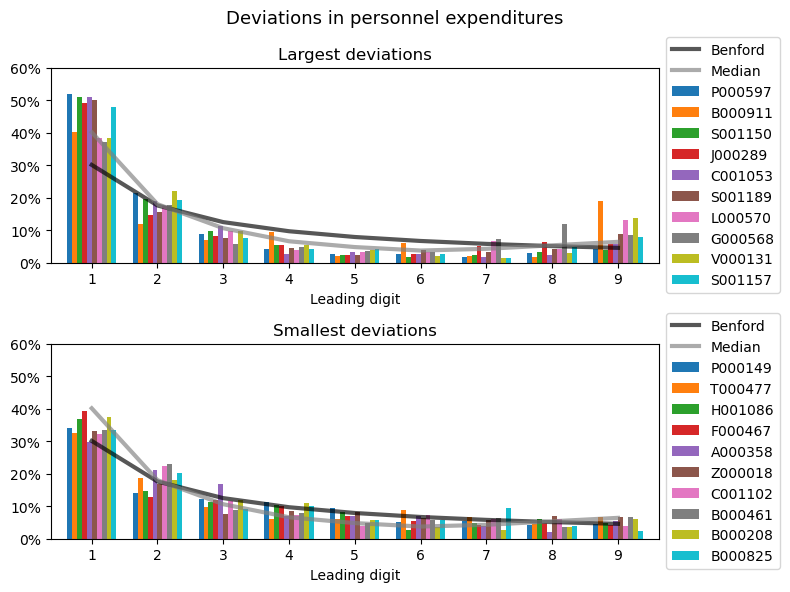

In [43]:
f,axs = plt.subplots(2,1,figsize=(8,6),sharey=True,subplot_kw={'ylim':(0,.6)})

top10_members_personnel.plot(kind='bar',width=.75,ax=axs[0],legend=False)
axs[0].set_title('Largest deviations')

bot10_members_personnel.plot(kind='bar',width=.75,ax=axs[1],legend=False)
axs[1].set_title('Smallest deviations')

for _ax in axs:
    _ax.plot(benfords_s,c='k',lw=3,alpha=.66,label='Benford')
    _ax.plot(leading_digit_personnel_median_norm,c='grey',lw=3,alpha=.66,label='Median')
    _ax.legend(loc='center left',bbox_to_anchor=(1,.5))
    _ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    _ax.set_xticklabels(range(1,10), rotation = 0)
    _ax.set_xlabel('Leading digit')

f.suptitle('Deviations in personnel expenditures',fontsize=13)

f.tight_layout()

f.savefig('benford_personnel_top_bot_10.png',bbox_inches='tight')

Within member, by year, across categories. Biggest member-year-category deviations from Benfords'

In [44]:
annual_member_cat_leading_digits_df = members_df.groupby(['BIOGUIDE_ID','YEAR','CATEGORY'])['AMOUNT'].apply(leading_digits_count)
annual_member_cat_leading_digits_df.head()

BIOGUIDE_ID  YEAR  CATEGORY       
A000022      2011  EQUIPMENT     1    12
                                 2     7
                                 4     1
                   FRANKED MAIL  1     7
                                 2     1
Name: AMOUNT, dtype: int64

In [45]:
annual_member_cat_leading_digits_df.unstack([2,1]).sort_index(axis=1)

CATEGORY      BENEFITS TO FORMER PERSONNEL EQUIPMENT                       \
YEAR                                  2017      2011  2012 2013 2014 2015   
BIOGUIDE_ID                                                                 
A000022     1                          NaN     12.00 12.00 1.00  NaN  NaN   
            2                          NaN      7.00  1.00  NaN  NaN  NaN   
            3                          NaN       NaN   NaN  NaN  NaN  NaN   
            4                          NaN      1.00   NaN  NaN  NaN  NaN   
            5                          NaN       NaN   NaN  NaN  NaN  NaN   
...                                    ...       ...   ...  ...  ...  ...   
Z000018     5                          NaN       NaN   NaN  NaN  NaN 1.00   
            6                          NaN       NaN   NaN  NaN  NaN  NaN   
            7                          NaN       NaN   NaN  NaN  NaN 1.00   
            8                          NaN       NaN   NaN  NaN  NaN 1.00   
            9                          NaN       NaN   NaN  NaN  NaN  NaN   

CATEGORY                                         FRANKED MAIL                 \
YEAR          2016 2017 2018 2019 2020 2021 2022         2011 2012 2013 2014   
BIOGUIDE_ID                                                                    
A000022     1  NaN  NaN  NaN  NaN  NaN  NaN  NaN         7.00 5.00  NaN  NaN   
            2  NaN  NaN  NaN  NaN  NaN  NaN  NaN         1.00 3.00 1.00  NaN   
            3  NaN  NaN  NaN  NaN  NaN  NaN  NaN         1.00 1.00  NaN  NaN   
            4  NaN  NaN  NaN  NaN  NaN  NaN  NaN         3.00 1.00  NaN  NaN   
            5  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN 1.00 1.00  NaN   
...            ...  ...  ...  ...  ...  ...  ...          ...  ...  ...  ...   
Z000018     5  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            6  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            7  NaN 1.00  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            8  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            9  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   

CATEGORY                                              OTHER SERVICES        \
YEAR          2015 2016 2017 2018 2019 2020 2021 2022           2011  2012   
BIOGUIDE_ID                                                                  
A000022     1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN          17.00  2.00   
            2  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN          20.00 13.00   
            3  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN           4.00 10.00   
            4  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN           1.00   NaN   
            5  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN           3.00  1.00   
...            ...  ...  ...  ...  ...  ...  ...  ...            ...   ...   
Z000018     5  NaN 1.00  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            6  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            7 1.00 2.00  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            8 1.00  NaN  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            9 2.00 1.00 1.00  NaN  NaN  NaN  NaN  NaN            NaN   NaN   

CATEGORY                                                          \
YEAR          2013 2014 2015  2016 2017 2018 2019 2020 2021 2022   
BIOGUIDE_ID                                                        
A000022     1 2.00  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            2  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            3 3.00  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            4  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            5  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...            ...  ...  ...   ...  ...  ...  ...  ...  ...  ...   
Z000018     5  NaN  NaN 1.00   NaN 3.00  NaN  NaN  NaN  NaN  NaN   
            6  NaN  NaN  Na

### Relative size factor

Divide biggest expense by second biggest expense (within member-category-time).

In [46]:
two_largest_expenses = members_df.groupby(['BIOGUIDE_ID','YEAR','CATEGORY']).agg({'AMOUNT':lambda x:x.nlargest(2)})['AMOUNT']

two_largest_expenses = two_largest_expenses[two_largest_expenses.apply(lambda x:isinstance(x,np.ndarray))]
two_largest_expenses = two_largest_expenses[(two_largest_expenses.apply(lambda x:x[0] > 0)) & (two_largest_expenses.apply(lambda x:x[1] > 0))]

largest_expenses_ratio = two_largest_expenses.apply(lambda x:x[0]/x[1])

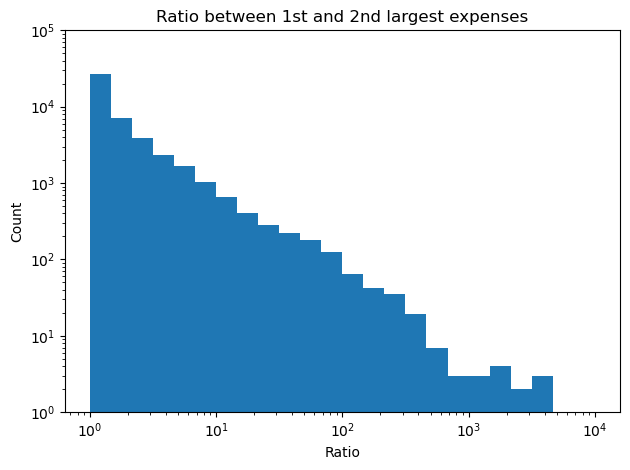

In [47]:
f,ax = plt.subplots()

largest_expenses_ratio.hist(bins=np.logspace(0,4,25),ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(None)
ax.set_ylim((1e0,1e5))
ax.set_xlabel('Ratio')
ax.set_ylabel('Count')
ax.set_title('Ratio between 1st and 2nd largest expenses')

f.tight_layout()
f.savefig('two_largest_ratio.png',bbox_inches='tight')

In [48]:
len(largest_expenses_ratio[largest_expenses_ratio <= 10]) / len(largest_expenses_ratio)

0.9542081689952537

In [49]:
largest_expenses_ratio[largest_expenses_ratio > 500].sort_index()

BIOGUIDE_ID  YEAR  CATEGORY                 
B001311      2022  FRANKED MAIL                 675.18
C001077      2019  PRINTING AND REPRODUCTION    716.32
C001118      2022  OTHER SERVICES              2310.00
D000533      2019  FRANKED MAIL                2076.64
E000071      2021  FRANKED MAIL                2001.70
F000461      2021  FRANKED MAIL                6822.95
G000571      2021  FRANKED MAIL                 582.02
K000390      2019  FRANKED MAIL                3512.39
L000551      2022  FRANKED MAIL                1048.24
L000573      2019  FRANKED MAIL                1164.02
L000574      2013  PRINTING AND REPRODUCTION    604.78
L000581      2022  FRANKED MAIL                 582.08
M001137      2020  FRANKED MAIL                 776.66
P000096      2022  FRANKED MAIL                2038.29
P000604      2016  FRANKED MAIL                 783.23
             2019  FRANKED MAIL                2967.06
             2020  FRANKED MAIL                3510.64
             2021  F

In [50]:
c0 = members_df['YEAR'] == 2021
c1 = members_df['CATEGORY'] == 'FRANKED MAIL'
c2 = members_df['BIOGUIDE_ID'] == 'P000604'

members_df.loc[c0 & c1 & c2,:].sort_values('AMOUNT',ascending=False)

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
4308923,2021Q4,P000604,2021 HON. DONALD M. PAYNE JR.,Q4,FRANKED MAIL,2021-12-30,UNITED STATES POSTAL SERVICE,2021-11-01,2021-11-30,FRANKED MAIL,44504.54,2021,AP,1509423,NaN,OFFICIAL EXPENSES OF MEMBERS,2
4017621,2021Q1,P000604,2021 HON. DONALD M. PAYNE JR.,Q1,FRANKED MAIL,2021-03-31,UNITED STATES POSTAL SERVICE,2021-02-01,2021-02-28,FRANKED MAIL,23.88,2021,AP,1403198,NaN,OFFICIAL EXPENSES OF MEMBERS,7
4207620,2021Q3,P000604,2021 HON. DONALD M. PAYNE JR.,Q3,FRANKED MAIL,2021-08-10,UNITED STATES POSTAL SERVICE,2021-06-01,2021-06-30,FRANKED MAIL,11.99,2021,AP,1448678,NaN,OFFICIAL EXPENSES OF MEMBERS,1
4017690,2021Q1,P000604,2020 HON. DONALD M. PAYNE JR.,Q1,FRANKED MAIL,2021-01-28,UNITED STATES POSTAL SERVICE,2020-12-01,2021-01-02,FRANKED MAIL,8.24,2021,AP,1379944,NaN,OFFICIAL EXPENSES OF MEMBERS,7
4308921,2021Q4,P000604,2021 HON. DONALD M. PAYNE JR.,Q4,FRANKED MAIL,2021-11-30,UNITED STATES POSTAL SERVICE,2021-10-01,2021-10-31,FRANKED MAIL,7.71,2021,AP,1496444,NaN,OFFICIAL EXPENSES OF MEMBERS,2
4017620,2021Q1,P000604,2021 HON. DONALD M. PAYNE JR.,Q1,FRANKED MAIL,2021-03-01,UNITED STATES POSTAL SERVICE,2021-01-03,2021-01-31,FRANKED MAIL,4.80,2021,AP,1391759,NaN,OFFICIAL EXPENSES OF MEMBERS,7
4111922,2021Q2,P000604,2021 HON. DONALD M. PAYNE JR.,Q2,FRANKED MAIL,2021-06-23,UNITED STATES POSTAL SERVICE,2021-05-01,2021-05-31,FRANKED MAIL,3.80,2021,AP,1435123,NaN,OFFICIAL EXPENSES OF MEMBERS,8
4207621,2021Q3,P000604,2021 HON. DONALD M. PAYNE JR.,Q3,FRANKED MAIL,2021-09-01,UNITED STATES POSTAL SERVICE,2021-07-01,2021-07-31,FRANKED MAIL,3.00,2021,AP,1460065,NaN,OFFICIAL EXPENSES OF MEMBERS,1
4308920,2021Q4,P000604,2021 HON. DONALD M. PAYNE JR.,Q4,FRANKED MAIL,2021-10-31,,2021-10-20,2021-10-31,FRANKED MAIL,-8.85,2021,GL,FLG0110648,NaN,OFFICIAL EXPENSES OF MEMBERS,2
4308922,2021Q4,P000604,2021 HON. DONALD M. PAYNE JR.,Q4,FRANKED MAIL,2021-11-30,,2021-11-20,2021-11-30,FRANKED MAIL,-16.95,2021,GL,FLG0111311,NaN,OFFICIAL EXPENSES OF MEMBERS,2


(0.0, 12000.0)

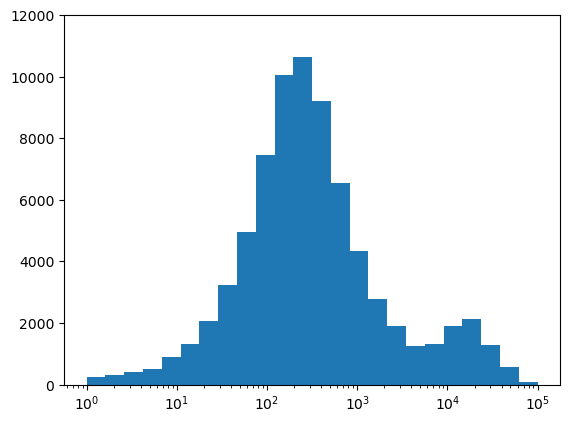

In [51]:
# ax = members_df[c1].groupby(['YEAR','BIOGUIDE_ID']).agg({'AMOUNT':'sum'})['AMOUNT'].hist(bins=np.logspace(0,7,25))
ax = members_df.loc[c1,'AMOUNT'].hist(bins=np.logspace(0,5,25))
ax.set_xscale('log')
ax.grid(None)
ax.set_ylim((0,12000))

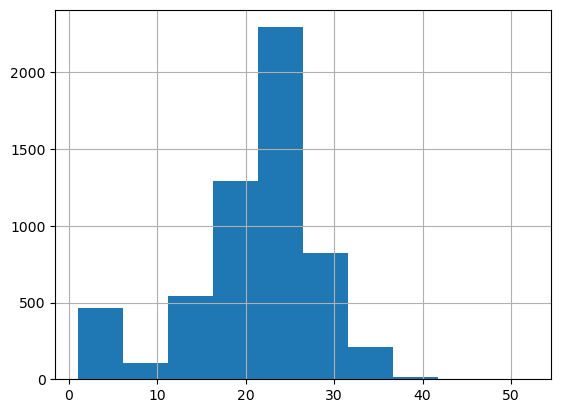

In [52]:
ax = members_df[c1].groupby(['YEAR','BIOGUIDE_ID']).agg({'AMOUNT':'nunique'})['AMOUNT'].hist()

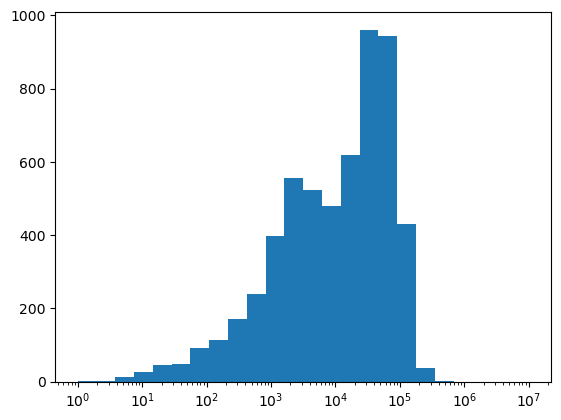

In [53]:
_s = members_df[c1].groupby(['YEAR','BIOGUIDE_ID']).agg({'AMOUNT':'sum'})['AMOUNT']
ax = _s.hist(bins=np.logspace(0,7,25))
ax.set_xscale('log')
ax.grid(None)

In [54]:
_s.describe()

count     5752.00
mean     29975.08
std      38323.04
min     -19684.53
25%       2153.53
50%      14060.08
75%      45778.57
max     449260.41
Name: AMOUNT, dtype: float64

In [55]:
members_df[members_df['BIOGUIDE_ID'] == 'P000604']

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
812098,2012Q4,P000604,HON. DONALD PAYNE JR,Q4,PERSONNEL COMPENSATION,NaT,"ALEXANDER, LAVERNE",2012-11-08,2012-12-31,CHIEF OF STAFF,22819.45,2012,NaN,NaN,"ALEXANDER, LAVERNE",NaN,6
812099,2012Q4,P000604,HON. DONALD PAYNE JR,Q4,PERSONNEL COMPENSATION,NaT,"CAMPBELL, PATRICIA M",2012-11-08,2012-12-31,STAFF ASSISTANT,2745.70,2012,NaN,NaN,"CAMPBELL, PATRICIA M",NaN,6
812100,2012Q4,P000604,HON. DONALD PAYNE JR,Q4,PERSONNEL COMPENSATION,NaT,"COLLIER, TIA",2012-11-08,2012-12-31,SENIOR LEGISLATIVE ASSISTANT,8659.61,2012,NaN,NaN,"COLLIER, TIA",NaN,6
812101,2012Q4,P000604,HON. DONALD PAYNE JR,Q4,PERSONNEL COMPENSATION,NaT,"CRUZ, ISABEL",2012-11-08,2012-12-31,SPECIAL ASSISTANT,11172.70,2012,NaN,NaN,"CRUZ, ISABEL",NaN,6
812102,2012Q4,P000604,HON. DONALD PAYNE JR,Q4,PERSONNEL COMPENSATION,NaT,"HATCHETT, YVONNE",2012-11-08,2012-12-31,SPECIAL ASSISTANT,6133.28,2012,NaN,NaN,"HATCHETT, YVONNE",NaN,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756057,2022Q4,P000604,2022 HON. DONALD M. PAYNE JR.,Q4,SUPPLIES AND MATERIALS,2022-12-31,,2022-12-01,2022-12-31,OFFICE SUPPLY (TRANSFER),76.55,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4756058,2022Q4,P000604,2022 HON. DONALD M. PAYNE JR.,Q4,EQUIPMENT,2022-10-31,,2022-10-01,2022-10-31,MAINTENANCE / REPAIRS,416.00,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4756059,2022Q4,P000604,2022 HON. DONALD M. PAYNE JR.,Q4,EQUIPMENT,2022-11-30,,2022-11-01,2022-11-30,MAINTENANCE / REPAIRS,416.00,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4756060,2022Q4,P000604,2022 HON. DONALD M. PAYNE JR.,Q4,EQUIPMENT,2022-12-30,,2022-12-01,2022-12-31,MAINTENANCE / REPAIRS,416.00,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6


## Categorical anomalies

In [56]:
member_expense_count_by_category_df = members_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID'])
member_expense_count_by_category_df = member_expense_count_by_category_df['CATEGORY'].value_counts().unstack(-1).fillna(0)
member_expense_count_by_category_df.drop(columns=['BENEFITS TO FORMER PERSONNEL','PERSONNEL BENEFITS','TRANSPORTATION OF THINGS'],inplace=True)

member_expense_count_by_category_df

CATEGORY                  EQUIPMENT  FRANKED MAIL  OTHER SERVICES  \
YEAR-QUARTER BIOGUIDE_ID                                            
2011Q1       A000014           0.00          0.00            0.00   
             A000022           7.00          5.00           11.00   
             A000055           3.00          4.00           12.00   
             A000210           3.00          7.00           16.00   
             A000358           5.00          7.00            7.00   
...                             ...           ...             ...   
2022Q4       W000826           5.00          8.00           17.00   
             Y000033           0.00          0.00            1.00   
             Y000062           3.00          4.00           25.00   
             Y000067           2.00          0.00            3.00   
             Z000017           4.00          4.00           11.00   

CATEGORY                  PERSONNEL COMPENSATION  PRINTING AND REPRODUCTION  \
YEAR-QUARTER BIOGUIDE_ID                                                      
2011Q1       A000014                        1.00                       0.00   
             A000022                       35.00                       9.00   
             A000055                       42.00                      12.00   
             A000210                       38.00                       1.00   
             A000358                       34.00                       7.00   
...                                          ...                        ...   
2022Q4       W000826                       23.00                      24.00   
             Y000033                        0.00                       0.00   
             Y000062                       21.00                       3.00   
             Y000067                       12.00                       0.00   
             Z000017                       20.00                       3.00   

CATEGORY                  RENT COMMUNICATION UTILITIES  \
YEAR-QUARTER BIOGUIDE_ID                                 
2011Q1       A000014                              0.00   
             A000022                             65.00   
             A000055                             72.00   
             A000210                             62.00   
             A000358                             47.00   
...                                                ...   
2022Q4       W000826                             58.00   
             Y000033                              2.00   
             Y000062                             35.00   
             Y000067                              7.00   
             Z000017                             42.00   

CATEGORY                  SUPPLIES AND MATERIALS  TRAVEL  
YEAR-QUARTER BIOGUIDE_ID                                  
2011Q1       A000014                        0.00    0.00  
             A000022                       52.00   26.00  
             A000055                       48.00   47.00  
             A000210                       24.00    3.00  
             A000358                       42.00   37.00  
...                                          ...     ...  
2022Q4       W000826                       32.00   72.00  
             Y000033                        0.00    0.00  
             Y000062                       25.00   33.00  
             Y000067                        4.00    0.00  
             Z000017                       29.00   17.00  

[22678 rows x 8 columns]

In [57]:
gt10 = member_expense_count_by_category_df.sum(1)
gt10 = gt10[gt10>20]
gt10 = member_expense_count_by_category_df.loc[gt10.index]

_exp = gt10.median(axis=0)
_exp = _exp/_exp.sum()
_df = gt10.div(gt10.sum(1),axis=0)

chisquare_pvalues_expense_counts = pd.Series(data=stats.chisquare(_df,_exp,axis=1).pvalue,index=gt10.index)
gt10.loc[chisquare_pvalues_expense_counts.sort_values().head(20).index]


CATEGORY                  EQUIPMENT  FRANKED MAIL  OTHER SERVICES  \
YEAR-QUARTER BIOGUIDE_ID                                            
2015Q3       M000485          24.00          0.00            0.00   
2019Q4       R000580           0.00          0.00            0.00   
2021Q1       W000810          15.00          1.00            0.00   
2017Q3       M001182           9.00          0.00            1.00   
2020Q3       S001209           3.00          8.00            6.00   
2022Q3       S001219           0.00          0.00            1.00   
             C001090           8.00          5.00            8.00   
2011Q1       H001039           1.00          1.00            0.00   
2020Q3       A000376           6.00          9.00            6.00   
2015Q1       N000187           0.00          0.00            0.00   
2022Q4       H001090           3.00          6.00            0.00   
2013Q1       M001154           0.00          1.00            0.00   
2021Q1       T000470           0.00          1.00            0.00   
2020Q2       D000629          11.00          7.00           16.00   
2021Q1       C001094           0.00          0.00            4.00   
2013Q1       F000116          20.00          1.00            1.00   
2020Q3       C001110           5.00         10.00            3.00   
2011Q1       S000465           3.00          1.00            1.00   
2021Q2       T000470           0.00          0.00            0.00   
2015Q1       M001142           0.00          1.00            0.00   

CATEGORY                  PERSONNEL COMPENSATION  PRINTING AND REPRODUCTION  \
YEAR-QUARTER BIOGUIDE_ID                                                      
2015Q3       M000485                        0.00                       0.00   
2019Q4       R000580                       27.00                       0.00   
2021Q1       W000810                       11.00                       0.00   
2017Q3       M001182                        1.00                       4.00   
2020Q3       S001209                       21.00                      82.00   
2022Q3       S001219                       21.00                       1.00   
             C001090                       29.00                     122.00   
2011Q1       H001039                       47.00                       0.00   
2020Q3       A000376                       21.00                      71.00   
2015Q1       N000187                       30.00                       0.00   
2022Q4       H001090                       24.00                      85.00   
2013Q1       M001154                       25.00                       0.00   
2021Q1       T000470                       19.00                       0.00   
2020Q2       D000629                       25.00                     149.00   
2021Q1       C001094                       33.00                       0.00   
2013Q1       F000116                       16.00                       0.00   
2020Q3       C001110                       21.00                      93.00   
2011Q1       S000465                       36.00                       0.00   
2021Q2       T000470                        0.00                       0.00   
2015Q1       M001142                       19.00                       1.00   

CATEGORY                  RENT COMMUNICATION UTILITIES  \
YEAR-QUARTER BIOGUIDE_ID                                 
2015Q3       M000485                              0.00   
2019Q4       R000580                              0.00   
2021Q1       W000810                              7.00   
2017Q3       M001182                              7.00   
2020Q3       S001209                             18.00   
2022Q3       S001219                              0.00   
             C001090                             34.00   
2011Q1       H001039                              4.00   
2020Q3       A000376                             15.00   
2015Q1       N000187                              6.00   
2022Q4       H001090                          

C:\Users\Brian\AppData\Local\Temp\ipykernel_31668\1303565720.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


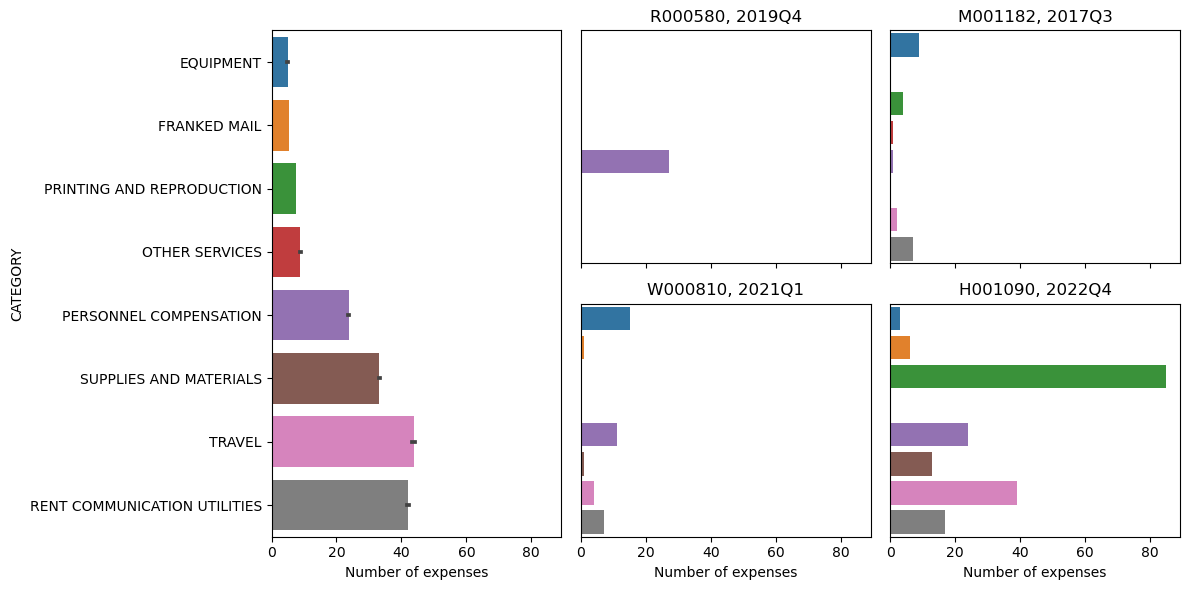

In [58]:
_df = member_expense_count_by_category_df.stack().reset_index(level=[2])

axd = plt.figure(figsize=(12,6),layout='constrained').subplot_mosaic(
    """
    ABD
    ACE
    """,
    sharex=True,
)

_order = member_expense_count_by_category_df.median().sort_values().index

sb.barplot(
    data = _df,
    x = 0,
    y = 'CATEGORY',
    order = _order,
    ax = axd['A']
)
axd['A'].set_xlabel("Number of expenses")

sb.barplot(
    data = _df.loc[chisquare_pvalues_expense_counts.sort_values().head(20).index[1]],
    x = 0,
    y = 'CATEGORY',
    order = _order,
    ax = axd['B']
)
axd['B'].yaxis.set_major_locator(mtick.NullLocator())
axd['B'].set_xlabel(None)
axd['B'].set_ylabel(None)
axd['B'].set_title("{1}, {0}".format(*chisquare_pvalues_expense_counts.sort_values().head(20).index[1]))

sb.barplot(
    data = _df.loc[chisquare_pvalues_expense_counts.sort_values().head(20).index[2]],
    x = 0,
    y = 'CATEGORY',
    order = _order,
    ax = axd['C']
)
axd['C'].yaxis.set_major_locator(mtick.NullLocator())
axd['C'].set_xlabel("Number of expenses")
axd['C'].set_ylabel(None)
axd['C'].set_title("{1}, {0}".format(*chisquare_pvalues_expense_counts.sort_values().head(20).index[2]))

sb.barplot(
    data = _df.loc[chisquare_pvalues_expense_counts.sort_values().head(20).index[3]],
    x = 0,
    y = 'CATEGORY',
    order = _order,
    ax = axd['D']
)
axd['D'].yaxis.set_major_locator(mtick.NullLocator())
axd['D'].set_xlabel(None)
axd['D'].set_ylabel(None)
axd['D'].set_title("{1}, {0}".format(*chisquare_pvalues_expense_counts.sort_values().head(20).index[3]))

sb.barplot(
    data = _df.loc[chisquare_pvalues_expense_counts.sort_values().head(20).index[10]],
    x = 0,
    y = 'CATEGORY',
    order = _order,
    ax = axd['E']
)
axd['E'].yaxis.set_major_locator(mtick.NullLocator())
axd['E'].set_xlabel("Number of expenses")
axd['E'].set_ylabel(None)
axd['E'].set_title("{1}, {0}".format(*chisquare_pvalues_expense_counts.sort_values().head(20).index[10]))

plt.tight_layout()
plt.savefig('category_counts.png',dpi=300,bbox_inches='tight')

In [60]:
c0 = members_df['YEAR-QUARTER'] == '2019Q4'
c1 = members_df['BIOGUIDE_ID'] == 'R000580'
members_df.loc[c0 & c1,:]

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
3558398,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,BILLMAN JEFFREY R,2018-01-01,2018-01-30,CONGRESSIONAL ASSISTANT,-546.73,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558399,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,CAMPUZANO NEFTALI,2018-01-01,2018-01-30,DEPUTY DISTRICT DIRECTOR,-518.95,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558400,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,CORRIGAN EDWARD M,2018-01-01,2018-01-30,LEGISLATIVE CORRESPONDENT,-668.95,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558401,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,FAWELL JOSEPH D,2018-01-01,2018-01-30,LEGISLATIVE ASSISTANT,-546.72,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558402,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,GOLLINGER JOSEPH B,2018-01-01,2018-01-30,STAFF ASSISTANT,-763.39,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558403,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,HILLSTROM EMILY E,2018-01-01,2018-01-30,STAFF ASSISTANT,-768.95,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558404,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,KALLENBACH JOSEPH M,2018-01-01,2018-01-30,STAFF ASSISTANT,-735.62,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558405,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,KUBAS ANNA,2018-01-01,2018-01-30,CONGRESSIONAL ASSISTANT,-630.06,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558406,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,MORK DAVID I,2018-12-01,2018-12-31,CASEWORK MANAGER (OTHER COMPENSATION),-2700.92,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2
3558407,2019Q4,R000580,2018 HON. PETER J. ROSKAM,Q4,PERSONNEL COMPENSATION,NaT,PETERMAN RYAN C,2018-01-01,2018-01-30,CONSTITUENT ADVOCATE,-657.84,2019,,,NaN,OFFICIAL EXPENSES OF MEMBERS,2


In [61]:
members_df.loc[c0 & c1,'PAYEE'].value_counts()

PAYEE
BILLMAN JEFFREY R      2
CAMPUZANO NEFTALI      2
CORRIGAN EDWARD M      2
FAWELL JOSEPH D        2
GOLLINGER JOSEPH B     2
HILLSTROM EMILY E      2
KALLENBACH JOSEPH M    2
KUBAS ANNA             2
PETERMAN RYAN C        2
RAHMIL OMRI H          2
SALTER REBECCA G       2
SCHILLER HANNAH M.     2
VERA VERONICA L        2
MORK DAVID I           1
Name: count, dtype: int64

In [62]:
pd.to_datetime('2019Q4')

Timestamp('2019-10-01 00:00:00')

Compare spending by party.

In [63]:
member_quarterly_category_amount_df = members_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID','CATEGORY']).agg({'AMOUNT':'sum','OFFICE':len}).reset_index()

member_quarterly_category_amount_df.rename(columns={'OFFICE':'EXPENSE COUNT'},inplace=True)

member_quarterly_category_amount_df = pd.merge(
    left = member_quarterly_category_amount_df,
    right = propublica_members_df[['id','gender','party']].drop_duplicates(subset=['id']),
    left_on = 'BIOGUIDE_ID',
    right_on = 'id',
    how = 'left'
)

member_quarterly_category_amount_df.head()

,YEAR-QUARTER,BIOGUIDE_ID,CATEGORY,AMOUNT,EXPENSE COUNT,id,gender,party
0,2011Q1,A000014,PERSONNEL COMPENSATION,-16.67,1,A000014,M,D
1,2011Q1,A000022,EQUIPMENT,29771.60,7,A000022,M,D
2,2011Q1,A000022,FRANKED MAIL,1909.79,5,A000022,M,D
3,2011Q1,A000022,OTHER SERVICES,14544.05,11,A000022,M,D
4,2011Q1,A000022,PERSONNEL COMPENSATION,221917.86,35,A000022,M,D


In [64]:
c0 = member_quarterly_category_amount_df['EXPENSE COUNT'] >= 5
c1 = ~member_quarterly_category_amount_df['CATEGORY'].isin(['PERSONNEL BENEFITS','TRANSPORTATION OF THINGS'])
c2 = member_quarterly_category_amount_df['party'].isin(['D','R'])

clean_bio_cat_df = member_quarterly_category_amount_df[c0 & c1 & c2]

In [65]:
member_quarterly_category_amount_df.loc[~member_quarterly_category_amount_df['party'].isin(['D','R']),'id'].unique()

array(['S001177', nan], dtype=object)

EQUIPMENT: 0.000.
Men 7092±8051
Women 8319±9478

FRANKED MAIL: 0.551.
Men 9535±16192
Women 9346±16578

OTHER SERVICES: 0.232.
Men 12323±7439
Women 12491±8103

PERSONNEL COMPENSATION: 0.000.
Men 241390±59313
Women 249717±61859

PRINTING AND REPRODUCTION: 0.250.
Men 13518±22569
Women 14059±25465

RENT COMMUNICATION UTILITIES: 0.000.
Men 24712±10659
Women 27465±12690

SUPPLIES AND MATERIALS: 0.000.
Men 7690±8276
Women 8758±10139

TRAVEL: 0.000.
Men 12753±8545
Women 12014±8951



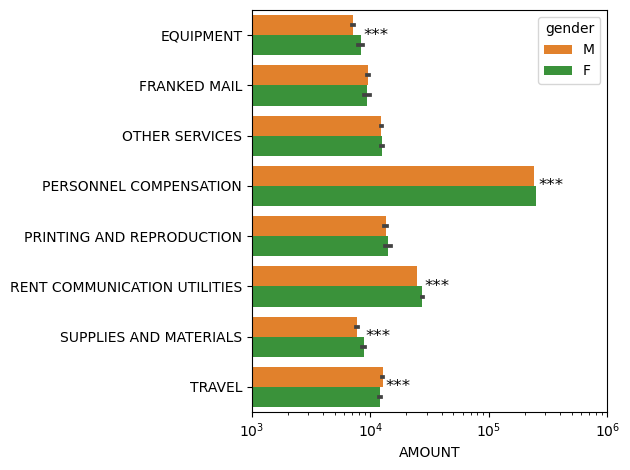

In [66]:
f,ax = plt.subplots()

sb.barplot(
    data = clean_bio_cat_df,
    x = 'AMOUNT',
    y = 'CATEGORY',
    hue = 'gender',
    width = .8,
    palette = ['tab:orange','tab:green'],
    ax = ax
)

ax.set_ylabel(None)
ax.set_xscale('log')
ax.set_xlim((1e3,1e6))

for i,_cat in enumerate(clean_bio_cat_df['CATEGORY'].unique()):
    _c0 = clean_bio_cat_df['CATEGORY'] == _cat
    _c_men = clean_bio_cat_df['gender'] == 'M'
    _c_women = clean_bio_cat_df['gender'] == 'F'
    
    _men = clean_bio_cat_df.loc[_c0 & _c_men,'AMOUNT']
    _women = clean_bio_cat_df.loc[_c0 & _c_women,'AMOUNT']
    
    _ttest = stats.ttest_ind(_men,_women)
    
    print("{0}: {1:.3f}.\nMen {2:.0f}±{3:.0f}\nWomen {4:.0f}±{5:.0f}\n".format(_cat,_ttest.pvalue,_men.mean(),_men.std(),_women.mean(),_women.std()))
    
    _mult = 1.33
    _max = np.max([_men.mean(),_women.mean()])
    
    if _ttest.pvalue < 0.001:
        ax.annotate('***',(_max.mean() * _mult, i),fontsize=12,ha='center',va='center')
    elif _ttest.pvalue < 0.01:
        ax.annotate('**',(_max.mean() * _mult, i + .25),fontsize=12,ha='center',va='center')
    elif _ttest.pvalue < 0.05:
        ax.annotate('*',(_max.mean() * _mult, i + .25),fontsize=12,ha='center',va='center')
        
f.tight_layout()
f.savefig('category_spending_gender.png',dpi=300,bbox_inches='tight')

EQUIPMENT: 3.2e-16
FRANKED MAIL: 2.1e-43
OTHER SERVICES: 2e-08
PERSONNEL COMPENSATION: 2.1e-107
PRINTING AND REPRODUCTION: 4e-05
RENT COMMUNICATION UTILITIES: 1.1e-236
SUPPLIES AND MATERIALS: 2e-19
TRAVEL: 8.8e-263


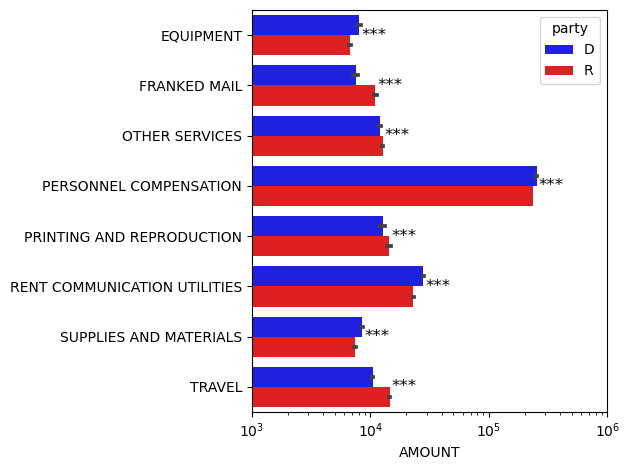

In [67]:
f,ax = plt.subplots()

sb.barplot(
    data = clean_bio_cat_df,
    x = 'AMOUNT',
    y = 'CATEGORY',
    hue = 'party',
    width = .8,
    palette = ['blue','red'],
    ax = ax
)

ax.set_ylabel(None)
ax.set_xscale('log')
ax.set_xlim((1e3,1e6))

for i,_cat in enumerate(clean_bio_cat_df['CATEGORY'].unique()):
    _c0 = clean_bio_cat_df['CATEGORY'] == _cat
    _c_dem = clean_bio_cat_df['party'] == 'D'
    _c_rep = clean_bio_cat_df['party'] == 'R'
    
    _dem = clean_bio_cat_df.loc[_c0 & _c_dem,'AMOUNT']
    _rep = clean_bio_cat_df.loc[_c0 & _c_rep,'AMOUNT']
    
    _ttest = stats.ttest_ind(_dem,_rep)
    
    print("{0}: {1:.2}".format(_cat,_ttest.pvalue))
    
    _mult = 1.33
    _max = np.max([_dem.mean(),_rep.mean()])
    
    if _ttest.pvalue < 0.001:
        ax.annotate('***',(_max.mean() * _mult, i),fontsize=12,ha='center',va='center')
    elif _ttest.pvalue < 0.01:
        ax.annotate('**',(_max.mean() * _mult, i + .25),fontsize=12,ha='center',va='center')
    elif _ttest.pvalue < 0.05:
        ax.annotate('*',(_max.mean() * _mult, i + .25),fontsize=12,ha='center',va='center')
        
f.tight_layout()
f.savefig('category_spending_party.png',dpi=300,bbox_inches='tight')

HC:
1. Pull list of members (systems controls) who "left/lost access/separated" and still getting compensated/reimbursed. Are payments acceptable? Cross-over between temporal and categorical anomalies.
2. Laurie website on fraud scores for members of congress and we validate against these results. External validity for our ensemble of scores.

## Temporal anomalies

In [68]:
members_travel_df = members_df[members_df['CATEGORY'] == 'TRAVEL']
members_travel_df.head()

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
6442,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-01-14,CITIBANK GOV CARD SERVICE,2011-01-04,2011-01-04,COMMERCIAL TRANSPORTATION,125.40,2011,AP,00071191,CITIBANK GOV CARD SERVICE,NaN,7
6443,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-02,INTABORO,2011-01-05,2011-01-05,TAXI/PARKING/TOLLS,93.14,2011,AP,00104251,INTABORO,NaN,7
6444,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-02,"MOSKOWITZ, JEDD I",2011-02-11,2011-02-11,TAXI/PARKING/TOLLS,12.00,2011,AP,00104259,"MOSKOWITZ, JEDD I",NaN,7
6445,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-02,"MOSKOWITZ, JEDD I",2011-02-17,2011-02-17,TAXI/PARKING/TOLLS,30.00,2011,AP,00104260,"MOSKOWITZ, JEDD I",NaN,7
6446,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-10,"MOSKOWITZ, JEDD I",2011-02-19,2011-02-19,MEALS,2.47,2011,AP,00111271,"MOSKOWITZ, JEDD I",NaN,7


#### Check for pre-billing

"END DATE" - "DATE" if negative: Travel advances vs. travel reimbursements

In [69]:
before_dates = members_travel_df['DATE'] - members_travel_df['START DATE']
before_dates = before_dates/pd.Timedelta(1,'d')
before_dates = before_dates[before_dates < 0]

In [70]:
members_travel_df.loc[before_dates.sort_values().index,'YEAR'].value_counts().sort_index()

YEAR
2011     62
2012     53
2013     54
2014     66
2015     52
2016     43
2017     26
2018     38
2019     43
2020     29
2021     31
2022    118
Name: count, dtype: int64

#### Check for impact of COVID-19

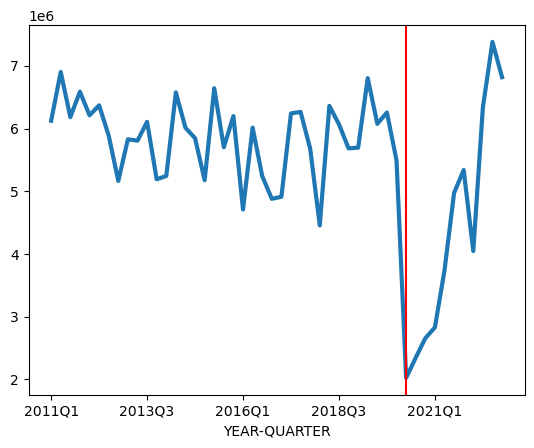

In [71]:
ax = members_travel_df.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT'].plot(lw=3)
ax.axvline(37,color='r')


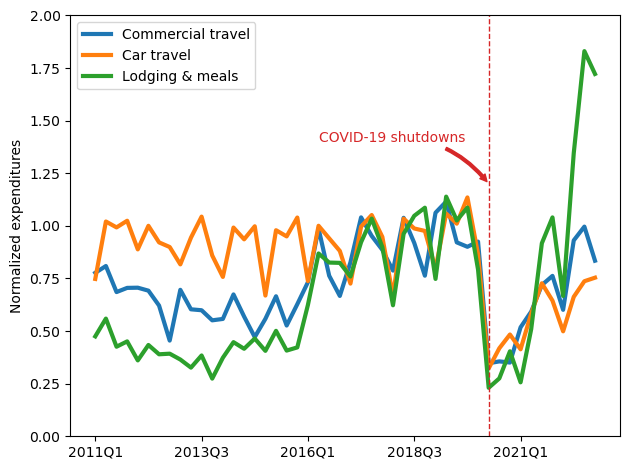

In [72]:
_df0 = members_travel_df[members_travel_df['PURPOSE'].isin(['COMMERCIAL TRANSPORTATION','AIRFARE COMMERCIAL TRANSPORT'])]
_df1 = members_travel_df[members_travel_df['PURPOSE'].isin(['PRIVATE AUTO MILEAGE','GASOLINE','TAXI/PARKING/TOLLS'])]
_df2 = members_travel_df[members_travel_df['PURPOSE'].isin(['LODGING','MEALS'])]

f,ax = plt.subplots()
_df0_agg = _df0.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT']
_df1_agg = _df1.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT']
_df2_agg = _df2.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT']

_df0_norm = _df0_agg.div(_df0_agg.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())
_df1_norm = _df1_agg.div(_df1_agg.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())
_df2_norm = _df2_agg.div(_df2_agg.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())

_df0_norm.plot(lw=3,ax=ax,label='Commercial travel')
_df1_norm.plot(lw=3,ax=ax,label='Car travel')
_df2_norm.plot(lw=3,ax=ax,label='Lodging & meals')

ax.axvline(37,color='tab:red',ls='--',lw=1)
ax.legend()
ax.set_ylim((0,2))
ax.set_ylabel('Normalized expenditures')
ax.set_xlabel(None)
ax.annotate(
    'COVID-19 shutdowns',
    xy=(37,1.2),
    xytext=(21,1.4),
    color='tab:red',
    arrowprops={
        'facecolor':'tab:red',
        'edgecolor':'tab:red',
        'arrowstyle':'simple',
        'connectionstyle':'arc3,rad=-0.25'
    }
)

f.tight_layout()
f.savefig('temporal_covid_shutdowns.png',dpi=300,bbox_inches='tight')

In [73]:
_df1_agg.iloc[36:48].shape,_df1_agg.iloc[24:36].shape

((12,), (12,))

In [74]:
stats.ttest_ind(_df1_agg.iloc[36:48],_df1_agg.iloc[24:36])

TtestResult(statistic=-5.617400821710344, pvalue=1.1984548179613055e-05, df=22.0)

HC: Break it on party affiliation to see how it changes.

In [77]:
travel_by_member = members_travel_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID']).agg({'AMOUNT':'sum'}).reset_index()

travel_by_member[['gender','party']] = travel_by_member['BIOGUIDE_ID'].apply(lambda x:pd.Series(bioguide_gender_party_map.get(x)))

travel_by_member.head()


,YEAR-QUARTER,BIOGUIDE_ID,AMOUNT,gender,party
0,2011Q1,A000022,4408.29,M,D
1,2011Q1,A000055,10240.27,M,R
2,2011Q1,A000210,4984.00,M,D
3,2011Q1,A000358,8645.69,M,R
4,2011Q1,A000361,38696.55,M,R


In [78]:
travel_by_member.groupby(['YEAR-QUARTER','party']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})

AMOUNT  BIOGUIDE_ID
YEAR-QUARTER party                        
2011Q1       D     2685338.57          265
             I       18202.92            1
             R     3421530.30          263
2011Q2       D     2642029.71          215
             I       21182.35            1
...                       ...          ...
2022Q3       I       64220.31            1
             R     4222709.65          216
2022Q4       D     2779697.00          220
             I       25682.57            1
             R     3975905.90          215

[144 rows x 2 columns]

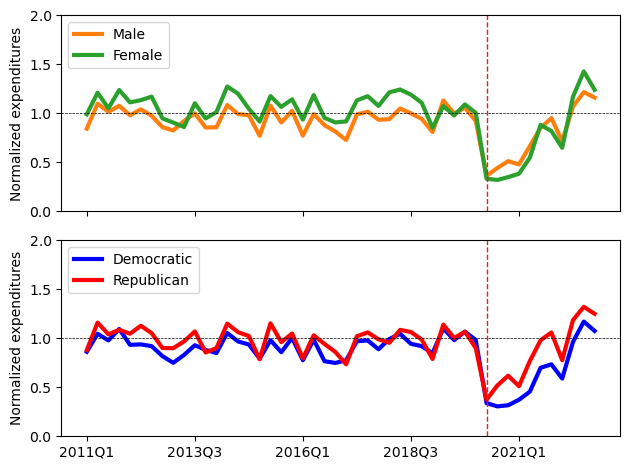

In [79]:
travel_gender_df = travel_by_member.groupby(['YEAR-QUARTER','gender']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})
travel_gender_df = travel_gender_df['AMOUNT'] / travel_gender_df['BIOGUIDE_ID']
travel_gender_df = travel_gender_df.unstack(1)
travel_gender_df = travel_gender_df.div(travel_gender_df.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())

travel_party_df = travel_by_member.groupby(['YEAR-QUARTER','party']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})
travel_party_df = travel_party_df['AMOUNT'] / travel_party_df['BIOGUIDE_ID']
travel_party_df = travel_party_df.unstack(1)
travel_party_df = travel_party_df.div(travel_party_df.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())

f,axs = plt.subplots(2,1,sharex=True)
travel_gender_df.loc[:,['M','F']].plot.line(ax=axs[0],lw=3,color=['tab:orange','tab:green'])
travel_party_df.loc[:,['D','R']].plot(ax=axs[1],lw=3,color=['blue','red'])

axs[0].set_ylim((0,2))
axs[1].set_ylim((0,2))

axs[0].legend(['Male','Female'],loc='upper left')
axs[1].legend(['Democratic','Republican'],loc='upper left')

axs[0].set_ylabel('Normalized expenditures')
axs[1].set_ylabel('Normalized expenditures')
axs[1].set_xlabel(None)

axs[0].axhline(1,ls='--',lw=.5,c='k')
axs[1].axhline(1,ls='--',lw=.5,c='k')

axs[0].axvline(37,color='tab:red',ls='--',lw=1)
axs[1].axvline(37,color='tab:red',ls='--',lw=1)

f.tight_layout()

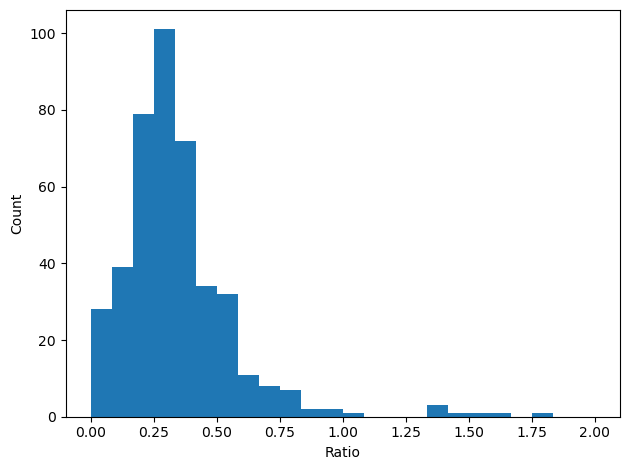

In [81]:
travel_by_member_pivot = travel_by_member.pivot(index=['BIOGUIDE_ID'],columns=['YEAR-QUARTER'],values='AMOUNT')

pandemic_impact_norm = travel_by_member_pivot.loc[:,'2020Q2'] / travel_by_member_pivot.loc[:,['2019Q1','2019Q2','2019Q3','2019Q4']].mean(1)
pandemic_impact_norm.dropna(inplace=True)

f,ax = plt.subplots()
pandemic_impact_norm.hist(bins=np.linspace(0,2,25),ax=ax)
ax.grid(None)
ax.set_xlabel('Ratio')
ax.set_ylabel('Count')

f.tight_layout()
f.savefig('pandemic_impact_hist.png',dpi=300,bbox_inches='tight')

In [82]:
len(pandemic_impact_norm[pandemic_impact_norm < 1]) / len(pandemic_impact_norm)

0.9788235294117648

In [83]:
pandemic_impact_norm[pandemic_impact_norm >= 1]

BIOGUIDE_ID
B001307   1.40
C001090   1.61
C001120   1.05
G000589   1.34
H001038   1.80
H001065   2.01
L000557   1.50
L000590   1.49
W000187   1.34
dtype: float64

In [84]:
pandemic_impact_norm.mean()

0.3448850131404217

In [85]:
travel_by_member_pivot.loc['H001065',['2019Q1','2019Q2','2019Q3','2019Q4']].mean(), travel_by_member_pivot.loc['H001065','2020Q2']


(6078.567500000001, 12191.21)

In [86]:
c0 = members_travel_df['BIOGUIDE_ID'] == 'H001065'
c1 = members_travel_df['YEAR-QUARTER'] == '2020Q2'
c2 = members_travel_df['CATEGORY'] == 'TRAVEL'
c3 = members_travel_df['PURPOSE'] == 'CAR RENTAL'
members_travel_df.loc[c0 & c1 & c2 & c3,:]#'AMOUNT'].sum()

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
3746747,2020Q2,H001065,2020 HON. GEORGE HOLDING,Q2,TRAVEL,2020-05-19,CITIBANK GOV CARD SERVICE,2020-04-10,2020-04-20,CAR RENTAL,1815.70,2020,AP,1289779,NaN,OFFICIAL EXPENSES OF MEMBERS,4
3746750,2020Q2,H001065,2020 HON. GEORGE HOLDING,Q2,TRAVEL,2020-06-17,CITIBANK GOV CARD SERVICE,2020-04-10,2020-05-12,CAR RENTAL,2826.71,2020,AP,1301094,NaN,OFFICIAL EXPENSES OF MEMBERS,4
3746751,2020Q2,H001065,2020 HON. GEORGE HOLDING,Q2,TRAVEL,2020-06-17,CITIBANK GOV CARD SERVICE,2020-05-12,2020-05-19,CAR RENTAL,687.12,2020,AP,1301094,NaN,OFFICIAL EXPENSES OF MEMBERS,4


In [87]:
members_travel_df.loc[c0 & c1 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'})

,AMOUNT
PURPOSE,
CAR RENTAL,5329.53
COMMERCIAL TRANSPORTATION,3131.00
GASOLINE,262.49
LODGING,2111.86
MEALS,118.24
TAXI/PARKING/TOLLS,1238.09


In [88]:
c0 = members_travel_df['BIOGUIDE_ID'] == 'H001065'
c1 = members_travel_df['YEAR-QUARTER'] == '2020Q2'
c2 = members_travel_df['CATEGORY'] == 'TRAVEL'
members_travel_df.loc[c0 & c1 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'})

,AMOUNT
PURPOSE,
CAR RENTAL,5329.53
COMMERCIAL TRANSPORTATION,3131.00
GASOLINE,262.49
LODGING,2111.86
MEALS,118.24
TAXI/PARKING/TOLLS,1238.09


In [89]:
c0 = members_travel_df['BIOGUIDE_ID'] == 'H001065'
c4 = members_travel_df['YEAR-QUARTER'] == '2019Q2'
c2 = members_travel_df['CATEGORY'] == 'TRAVEL'
members_travel_df.loc[c0 & c4 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'})

,AMOUNT
PURPOSE,
COMMERCIAL TRANSPORTATION,3723.14
MEALS,6.93
PRIVATE AUTO MILEAGE,334.48
TAXI/PARKING/TOLLS,1655.01


In [90]:
members_travel_df.loc[c0 & c1 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'}).loc['CAR RENTAL']/members_travel_df.loc[c1 & c2 & c3,:].groupby('BIOGUIDE_ID').agg({'AMOUNT':'sum'}).mean()

AMOUNT   6.85
dtype: float64

#### Cyclical spending

(1000.0, 1000000.0)

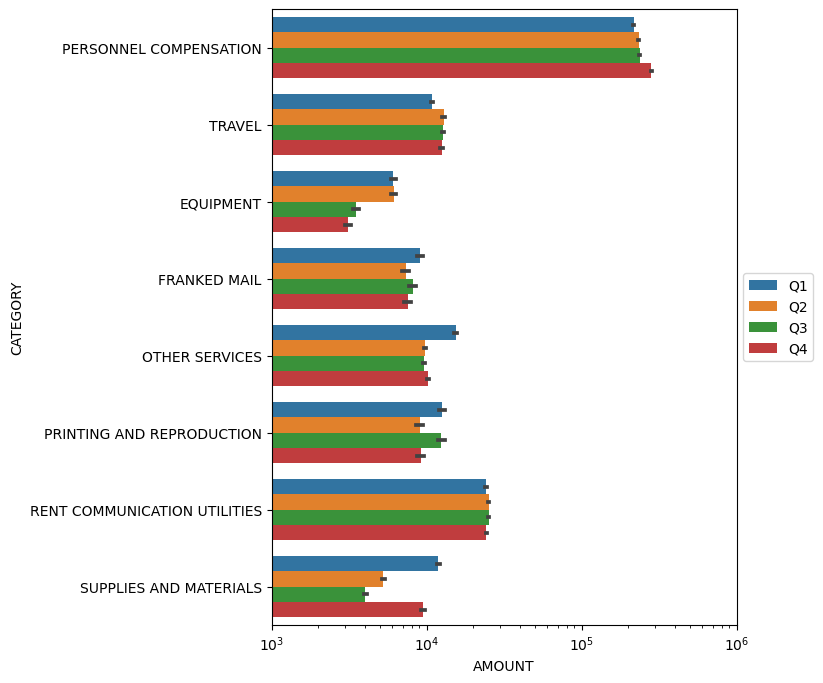

In [91]:
populated_categories = members_df['CATEGORY'].value_counts().index[:-3]
member_quarterly_spending_by_category_df = members_df[members_df['CATEGORY'].isin(populated_categories)]
member_quarterly_spending_by_category_df = member_quarterly_spending_by_category_df.groupby(['BIOGUIDE_ID','YEAR','QUARTER','CATEGORY']).agg({'AMOUNT':'sum'})
member_quarterly_spending_by_category_df.reset_index(inplace=True)

f,ax = plt.subplots(figsize=(6,8))
sb.barplot(
    data = member_quarterly_spending_by_category_df,
    x = 'AMOUNT',
    y = 'CATEGORY',
    hue = 'QUARTER',
    ax = ax
)

ax.legend(loc='center left',bbox_to_anchor=(1,.5))
ax.set_xscale('log')
ax.set_xlim((1e3,1e6))

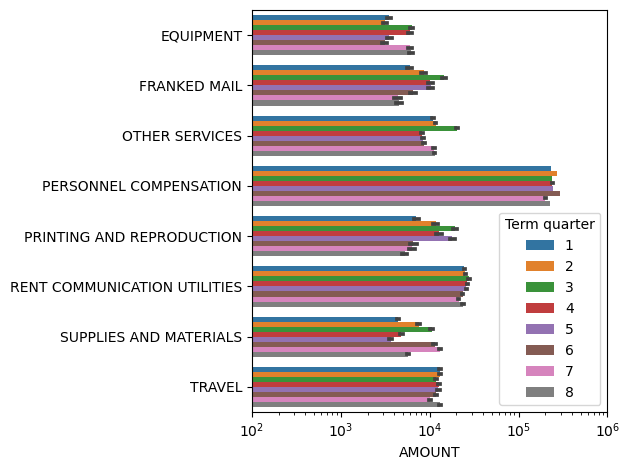

In [92]:
populated_categories = members_df['CATEGORY'].value_counts().index[:-3]
member_termly_spending_by_category_df = members_df[members_df['CATEGORY'].isin(populated_categories)]
member_termly_spending_by_category_df = member_termly_spending_by_category_df.groupby(['BIOGUIDE_ID','YEAR','TERM_QUARTER','CATEGORY']).agg({'AMOUNT':'sum'})
member_termly_spending_by_category_df.reset_index(inplace=True)

f,ax = plt.subplots()
sb.barplot(
    data = member_termly_spending_by_category_df,
    x = 'AMOUNT',
    y = 'CATEGORY',
    hue = 'TERM_QUARTER',
    order = sorted(member_termly_spending_by_category_df['CATEGORY'].unique()),
    ax = ax
)

ax.legend(title='Term quarter',loc='lower right')#,bbox_to_anchor=(1,.5))
ax.set_xscale('log')
ax.set_xlim((1e2,1e6))
ax.set_ylabel(None)

f.tight_layout()
f.savefig('spending_term_quarter.png',dpi=300,bbox_inches='tight')


Q3 AY is Q4 FY, members are spending down budgets in Q3 before appropriations.

HC: Comparing newcomer to incumbent, HC to find cite for govt expenditures increase in FY Q4

In [93]:
quarterly_category_spending = pd.pivot_table(
    data = member_quarterly_spending_by_category_df,
    index = 'CATEGORY',
    columns = 'QUARTER',
    values = 'AMOUNT',
    aggfunc = 'median'
)

quarterly_category_spending

QUARTER,Q1,Q2,Q3,Q4
CATEGORY,,,,
EQUIPMENT,2941.50,2905.25,1474.72,1300.80
FRANKED MAIL,1004.00,1111.52,1104.74,1116.33
OTHER SERVICES,11842.53,9675.00,9675.00,10005.00
PERSONNEL COMPENSATION,228465.45,231219.16,233148.60,273944.16
PRINTING AND REPRODUCTION,2292.81,1473.55,1708.64,1258.53
RENT COMMUNICATION UTILITIES,23552.24,24111.81,23881.81,23241.56
SUPPLIES AND MATERIALS,8881.79,4067.42,3190.54,6227.19
TRAVEL,9281.29,11680.67,11053.31,10937.28


In [94]:
for _cat in quarterly_category_spending.index:
    _obs = quarterly_category_spending.loc[_cat]
    _exp = [quarterly_category_spending.loc[_cat].mean()] * 4
    _chi2 = stats.chisquare(_obs,_exp)
    print(_cat,_chi2.pvalue)

EQUIPMENT 1.910937780601982e-238
FRANKED MAIL 0.04678119278285585
OTHER SERVICES 4.789902912512599e-68
PERSONNEL COMPENSATION 0.0
PRINTING AND REPRODUCTION 1.676610711468651e-76
RENT COMMUNICATION UTILITIES 0.0003742200389755118
SUPPLIES AND MATERIALS 0.0
TRAVEL 2.770560917721128e-63


In [95]:
quarterly_category_spending = pd.pivot_table(
    data = member_termly_spending_by_category_df,
    index = 'CATEGORY',
    columns = 'TERM_QUARTER',
    values = 'AMOUNT',
    aggfunc = 'median'
)

quarterly_category_spending

TERM_QUARTER,1,2,3,4,5,6,7,8
CATEGORY,,,,,,,,
EQUIPMENT,1509.30,1423.90,3243.23,2838.36,1428.00,1226.52,2710.22,2961.18
FRANKED MAIL,1106.70,1476.78,3988.34,1344.69,1102.07,880.55,568.47,988.88
OTHER SERVICES,10725.00,10989.00,17284.26,7228.50,7257.23,7567.77,10695.00,10935.00
PERSONNEL COMPENSATION,231404.82,267306.55,234780.51,233861.88,235239.10,281573.15,222268.05,228537.45
PRINTING AND REPRODUCTION,1451.12,1896.55,7439.24,1873.90,2551.08,837.04,1585.46,1292.30
RENT COMMUNICATION UTILITIES,23640.49,24385.16,25449.46,24638.63,24203.46,22073.56,21877.49,23718.86
SUPPLIES AND MATERIALS,3474.93,5515.63,8155.24,3736.33,2869.30,7507.97,9970.58,4497.07
TRAVEL,11718.59,12048.74,10293.16,11272.38,10435.67,9929.24,8440.38,12084.33


#### Interevent timing 

HC: Pre/post presidential election, do franked mail costs change in month before and after election?  
HC: Conscienciousness about filing expenses, auditing for good

In [96]:
interevent_data = members_df.copy().sort_values(['BIOGUIDE_ID','CATEGORY','DATE'],ascending=True)
interevent_data = interevent_data.groupby(['BIOGUIDE_ID','CATEGORY'])
interevent_data = interevent_data['DATE'].diff()/pd.Timedelta(1,'d')
interevent_data.dropna(inplace=True)

interevent_counts = interevent_data.value_counts()
interevent_counts.index.name = 'index'
interevent_counts.sort_index(inplace=True)

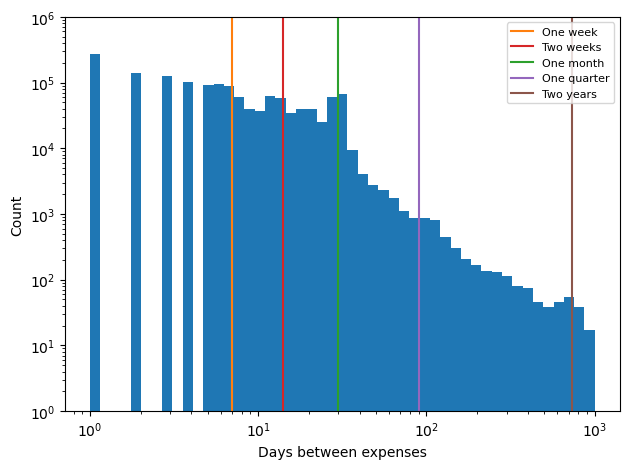

In [97]:
f,ax = plt.subplots()

interevent_data.hist(bins=np.logspace(0,3,50),grid=False,ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Days between expenses')
ax.set_ylabel('Count')
ax.set_ylim((1e0,1e6))

ax.axvline(7,c='tab:orange',label='One week')
ax.axvline(14,c='tab:red',label='Two weeks')
ax.axvline(30,c='tab:green',label='One month')
ax.axvline(90,c='tab:purple',label='One quarter')
ax.axvline(365*2,c='tab:brown',label='Two years')

ax.legend(fontsize=8)

f.tight_layout()
f.savefig('interevent_anomalies.png',dpi=300,bbox_inches='tight')

In [98]:
interevent_data.value_counts(normalize=1).sort_index().head(10)

DATE
0.00   0.56
1.00   0.08
2.00   0.04
3.00   0.04
4.00   0.03
5.00   0.03
6.00   0.03
7.00   0.03
8.00   0.02
9.00   0.01
Name: proportion, dtype: float64

In [99]:
interevent_data.value_counts().sort_index().reset_index()

,DATE,count
0,0.00,1840434
1,1.00,266947
2,2.00,141343
3,3.00,124806
4,4.00,103182
...,...,...
653,2795.00,1
654,2828.00,1
655,2893.00,1
656,3044.00,1


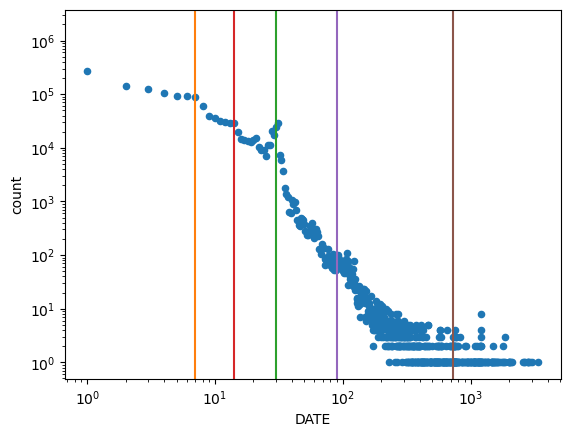

In [100]:
_df = interevent_data.value_counts().sort_index().reset_index()

ax = _df.plot(kind='scatter',x='DATE',y='count')
ax.set_xscale('log')
ax.set_yscale('log')

ax.axvline(7,c='tab:orange',label='One week')
ax.axvline(14,c='tab:red',label='Two weeks')
ax.axvline(30,c='tab:green',label='One month')
ax.axvline(90,c='tab:purple',label='One quarter')
ax.axvline(365*2,c='tab:brown',label='Two years')

HC: People at the 2-year bump are likely to have more discrepancies, they're loading up all their expenses at the end  
HC: Patterns hold up across categories? 90-day rule for reimbursements being taxable forcing stuff  
HC: Did rule change on reimbursements and how is that affecting behavior?  

## Spatial anomalies

HC: Compare members within state to each other, particularly for travel, Guam travel should be highest  
HC: Travel receipts for times when they were also voting?  
BK: Spatial patterns by office? Social influence/comparison could drive anomaly-generating behavior  

In [101]:
members_bioguide_travel_df = members_bioguide_df[members_bioguide_df['CATEGORY'] == 'TRAVEL']
members_bioguide_travel_df

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER,id,title,short_title,api_uri,first_name,middle_name,last_name,suffix,date_of_birth,gender,party,leadership_role,twitter_account,facebook_account,youtube_account,govtrack_id,cspan_id,votesmart_id,icpsr_id,crp_id,google_entity_id,fec_candidate_id,url,rss_url,contact_form,in_office,cook_pvi,dw_nominate,ideal_point,seniority,total_votes,missed_votes,total_present,last_updated,ocd_id,office,phone,fax,state,district,at_large,geoid,missed_votes_pct,votes_with_party_pct,votes_against_party_pct,next_election,congress
43,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-01-14,CITIBANK GOV CARD SERVICE,2011-01-04,2011-01-04,COMMERCIAL TRANSPORTATION,125.40,2011,AP,00071191,CITIBANK GOV CARD SERVICE,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,28.00,1655.00,132.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,7.98,98.75,1.19,2010.00,111.00
44,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-01-14,CITIBANK GOV CARD SERVICE,2011-01-04,2011-01-04,COMMERCIAL TRANSPORTATION,125.40,2011,AP,00071191,CITIBANK GOV CARD SERVICE,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,30.00,1607.00,143.00,3.00,2019-10-07 10:38:31 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,8.90,94.65,5.28,2012.00,112.00
45,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-02,INTABORO,2011-01-05,2011-01-05,TAXI/PARKING/TOLLS,93.14,2011,AP,00104251,INTABORO,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,28.00,1655.00,132.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,7.98,98.75,1.19,2010.00,111.00
46,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-02,INTABORO,2011-01-05,2011-01-05,TAXI/PARKING/TOLLS,93.14,2011,AP,00104251,INTABORO,NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,30.00,1607.00,143.00,3.00,2019-10-07 10:38:31 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,8.90,94.65,5.28,2012.00,112.00
47,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,TRAVEL,2011-03-02,"MOSKOWITZ, JEDD I",2011-02-11,2011-02-11,TAXI/PARKING/TOLLS,12.00,2011,AP,00104259,"MOSKOWITZ, JEDD I",NaN,7,A000022,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Gary,L.,Ackerman,NaN,1942-11-19,M,D,NaN,repgaryackerman,NaN,RepAckerman,400003.00,1002061.00,NaN,15080.00,NaN,/m/03rhdq,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,28.00,1655.00,132.00,0.00,2019-10-07 10:50:00 -0400,ocd-division/country:us/state:ny/cd:5,NaN,NaN,NaN,NY,5,False,3605.00,7.98,98.75,1.19,2010.00,111.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20294640,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,TRAVEL,2022-12-19,CITIBANK GOV CARD SERVICE,2022-11-17,2022-11-17,AIRFARE COMMERCIAL TRANSPORT,553.60,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6,Z000017,Representative,Rep.,https://api.propublica.org/congress/v1/members...,Lee,NaN,Zeldin,NaN,1980-

In [112]:
annual_member_travel = members_bioguide_travel_df.groupby(['state','YEAR']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})
annual_member_travel['per_member'] = annual_member_travel['AMOUNT'] / annual_member_travel['BIOGUIDE_ID']
annual_member_travel_per_member = annual_member_travel['per_member'].unstack('YEAR')
annual_member_travel_per_member.head()

YEAR,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
state,,,,,,,,,,,,
AK,1005910.99,1037389.08,633852.59,1009863.89,460628.98,746043.55,580944.70,873597.69,606969.65,368529.49,327877.13,193560.89
AL,305012.02,315779.99,319328.50,288752.98,312888.12,312870.60,356858.09,348413.33,415457.45,218933.34,230707.90,397159.67
AR,195538.88,215248.90,183909.15,272619.48,262611.50,379339.16,407713.10,400066.09,464251.36,239370.18,351576.06,428666.34
AS,226426.95,363877.98,224715.57,155014.56,184943.09,451166.65,384528.70,518290.50,375057.75,259502.45,82072.15,414058.95
AZ,231449.52,321600.87,261551.14,454602.19,358302.80,341704.55,316740.16,389890.53,366735.72,243635.87,362514.81,494236.39


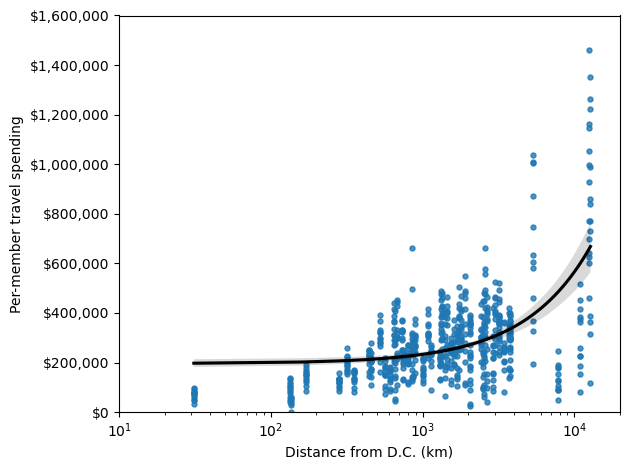

In [104]:
# avg_travel_spending = annual_member_travel_per_member.mean(axis=1).reset_index()
avg_travel_spending = annual_member_travel_per_member.stack().reset_index()
avg_travel_spending.columns = ['state','year','amount']

_merged = pd.merge(
    left = cop_df,
    right = avg_travel_spending,
    left_on = 'STUSAB',
    right_on = 'state',
    how = 'outer'
)

_merged = _merged[_merged['DC_DIST'] > 0]

f,ax = plt.subplots()
sb.regplot(data=_merged,x='DC_DIST',y='amount',line_kws={'color':'k'},scatter_kws={'s':13},ax=ax)
ax.set_xscale('log')
ax.set_xlim((1e1,2e4))
ax.set_xlabel('Distance from D.C. (km)')
ax.set_ylabel('Per-member travel spending')
ax.set_ylim((0,1.6e6))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

f.tight_layout()
f.savefig('travel_distance.png',dpi=300,bbox_inches='tight')

HC: Pull out the members with the largest deviation/residuals from the trend

In [105]:
dist_travel_reg = stats.linregress(_merged['DC_DIST'],_merged['amount'])
dist_travel_reg

LinregressResult(slope=36.939053900243245, intercept=196196.04394602103, rvalue=0.568919028949623, pvalue=1.9272170506034712e-57, stderr=2.0895771409633412, intercept_stderr=7458.70514529597)

In [106]:
dist_travel_reg.rvalue**2

0.32366886150098195

In [107]:
state_yhats = {}
for _state,_dist in cop_df[['STATE_NAME','DC_DIST']].values:
    state_yhats[_state] = dist_travel_reg.slope * _dist + dist_travel_reg.intercept
    
travel_dist_yhat_df = pd.DataFrame(data=state_yhats.values(),index=state_yhats.keys(),columns=['yhat'])

travel_dist_yhat_merged = pd.merge(
    left = _merged,
    right = travel_dist_yhat_df,
    left_on = 'STATE_NAME',
    right_index = True,
    how = 'left'
)

travel_dist_yhat_merged['residual'] = travel_dist_yhat_merged['amount'] - travel_dist_yhat_merged['yhat']
travel_dist_yhat_merged['residual_pct'] = travel_dist_yhat_merged['residual'] / travel_dist_yhat_merged['amount']

In [108]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual'].abs().nlargest(20).index]

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST,state,year,amount,yhat,residual,residual_pct
650,69,MP,Northern Mariana Islands,NaN,16.40,145.40,12465.71,MP,2018,1462166.96,656667.66,805499.30,0.55
634,66,GU,Guam,NaN,13.40,144.80,12775.61,GU,2014,1350088.95,668114.84,681974.11,0.51
13,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2012,1037389.08,394539.62,642849.46,0.62
15,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2014,1009863.89,394539.62,615324.27,0.61
12,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2011,1005910.99,394539.62,611371.37,0.61
632,66,GU,Guam,NaN,13.40,144.80,12775.61,GU,2012,1261145.30,668114.84,593030.46,0.47
635,66,GU,Guam,NaN,13.40,144.80,12775.61,GU,2015,1223790.85,668114.84,555676.01,0.45
640,66,GU,Guam,NaN,13.40,144.80,12775.61,GU,2020,118486.74,668114.84,-549628.10,-4.64
629,60,AS,American Samoa,NaN,14.30,170.70,10858.24,AS,2021,82072.15,597289.25,-515217.10,-6.28
648,69,MP,Northern Mariana Islands,NaN,16.40,145.40,12465.71,MP,2016,1161361.76,656667.66,504694.10,0.43


In [109]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual_pct'].abs().nlargest(20).index,'STATE_NAME'].value_counts()

STATE_NAME
Hawaii            5
Delaware          4
Maryland          3
North Dakota      2
American Samoa    1
New Mexico        1
Guam              1
Virginia          1
Wyoming           1
New Hampshire     1
Name: count, dtype: int64

In [110]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual_pct'].abs().nlargest(20).index,:]

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST,state,year,amount,yhat,residual,residual_pct
90,10,DE,Delaware,989948.00,39.33,-75.55,135.23,DE,2017,1889.04,201191.40,-199302.36,-105.50
404,38,ND,North Dakota,779094.00,47.34,-99.44,2041.31,ND,2012,26255.17,271599.99,-245344.82,-9.34
137,15,HI,Hawaii,1455271.00,21.11,-157.49,7766.39,HI,2021,50155.98,483079.11,-432923.13,-8.63
403,38,ND,North Dakota,779094.00,47.34,-99.44,2041.31,ND,2011,31749.47,271599.99,-239850.52,-7.55
629,60,AS,American Samoa,NaN,14.30,170.70,10858.24,AS,2021,82072.15,597289.25,-515217.10,-6.28
377,35,NM,New Mexico,2117522.00,34.61,-106.33,2649.20,NM,2021,41876.83,294055.11,-252178.28,-6.02
84,10,DE,Delaware,989948.00,39.33,-75.55,135.23,DE,2011,29657.94,201191.40,-171533.46,-5.78
244,24,MD,Maryland,6177224.00,39.14,-76.80,31.12,MD,2020,30944.07,197345.55,-166401.48,-5.38
640,66,GU,Guam,NaN,13.40,144.80,12775.61,GU,2020,118486.74,668114.84,-549628.10,-4.64
131,15,HI,Hawaii,1455271.00,21.11,-157.49,7766.39,HI,2015,89310.66,483079.11,-393768.44,-4.41


In [111]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual_pct'].nlargest(20).index,:]

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST,state,year,amount,yhat,residual,residual_pct
223,23,ME,Maine,1362359.00,44.27,-69.76,847.53,ME,2011,662967.65,227502.86,435464.79,0.66
13,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2012,1037389.08,394539.62,642849.46,0.62
15,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2014,1009863.89,394539.62,615324.27,0.61
12,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2011,1005910.99,394539.62,611371.37,0.61
662,78,VI,U.S. Virgin Islands,NaN,18.20,-64.60,2590.88,VI,2018,661727.20,291900.73,369826.47,0.56
650,69,MP,Northern Mariana Islands,NaN,16.40,145.40,12465.71,MP,2018,1462166.96,656667.66,805499.30,0.55
19,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2018,873597.69,394539.62,479058.07,0.55
224,23,ME,Maine,1362359.00,44.27,-69.76,847.53,ME,2012,495463.43,227502.86,267960.57,0.54
489,46,SD,South Dakota,886667.00,43.99,-98.92,1908.93,SD,2013,548991.60,266710.26,282281.34,0.51
536,50,VT,Vermont,643077.00,44.10,-72.82,674.20,VT,2012,453006.61,221100.25,231906.36,0.51


#### Office building proximity

In [ ]:
annual_category_spending = pd.pivot_table(
    data = members_df,
    index = ['YEAR','BIOGUIDE_ID'],
    columns = ['CATEGORY'],
    values = 'AMOUNT',
    aggfunc = 'sum'
)

# Filter to relevant years and columns
annual_category_spending = annual_category_spending.loc[2015:,top_cats]

# Calculate z-scores for spending in each category
# annual_category_spending_zscore = annual_category_spending.groupby(level=0).apply(stats.zscore,nan_policy='omit')
# annual_category_spending_zscore.index = annual_category_spending_zscore.index.droplevel(0)

annual_category_spending_office = pd.merge(
    left = annual_category_spending.reset_index(),
    right = member_office_df,
    left_on = ['BIOGUIDE_ID','YEAR'],
    right_on = ['bioguideID','year'],
    how = 'inner'
)

annual_category_spending_office['YEAR'] = annual_category_spending_office['YEAR'].astype('Int64')

annual_category_spending_office.head()

In [738]:
_df = annual_category_spending_zscore_office.set_index(['YEAR','BIOGUIDE_ID']).loc[:,top_cats].dropna(how='all')
_df

PERSONNEL COMPENSATION  FRANKED MAIL   TRAVEL  \
YEAR    BIOGUIDE_ID                                                  
2015.00 Y000033                  1064706.62       2089.09 65804.14   
        B001289                   882000.06      50206.23 48086.09   
        R000591                   995693.53      16519.01 60434.72   
        R000575                  1054408.61       7499.09 45601.38   
        A000055                   910757.11       9764.00 72235.60   
...                                     ...           ...      ...   
2022.00 G000579                  1161096.13     100524.33 48121.77   
        M001180                  1054867.93     100880.15 30570.99   
        M001195                   995858.53     203688.05 46638.86   
        M001205                  1445733.49        806.23 56032.76   
        C001109                  1602669.28        138.13 24333.52   

                     RENT COMMUNICATION UTILITIES  PRINTING AND REPRODUCTION  \
YEAR    BIOGUIDE_ID                                                            
2015.00 Y000033                          92184.16                    1413.03   
        B001289                         132996.42                   61123.73   
        R000591                          78237.98                    3336.23   
        R000575                          85499.61                    1410.90   
        A000055                          93374.57                    8340.59   
...                                           ...                        ...   
2022.00 G000579                          52710.02                  133221.99   
        M001180                          82813.51                  126257.90   
        M001195                         120532.37                  240886.70   
        M001205                          56329.85                    1759.40   
        C001109                          79548.53                     413.80   

                     OTHER SERVICES  SUPPLIES AND MATERIALS  EQUIPMENT  
YEAR    BIOGUIDE_ID                                                     
2015.00 Y000033            45411.83                16957.48    4446.94  
        B001289            32062.79                18080.45   11167.48  
        R000591            41406.63                17416.99   16337.82  
        R000575            35006.42                16997.38   30299.03  
        A000055            28794.12                38245.97   35383.90  
...                             ...                     ...        ...  
2022.00 G000579            45657.78                15473.01   15529.02  
        M001180            47280.00                21140.74    4780.03  
        M001195            53750.18                25727.11    6803.00  
        M001205            45697.37                18182.66    9347.86  
        C001109            40068.64                 4753.32   11090.18  

[3485 rows x 8 columns]

In [741]:
within_floor_std = annual_category_spending_office.groupby(['YEAR','office-floor']).agg({i:np.std for i in top_cats})

within_building_std = annual_category_spending_office.groupby(['YEAR','office-building']).agg({i:np.std for i in top_cats})

within_year_std = annual_category_spending_office.groupby(['YEAR']).agg({i:np.std for i in top_cats})


<Axes: xlabel='office-floor', ylabel='office-floor'>

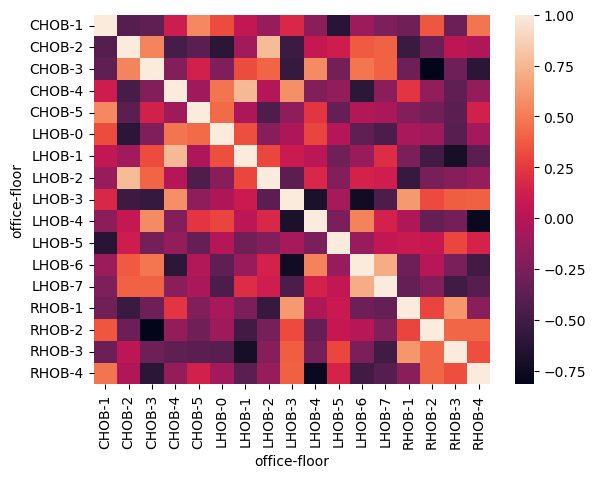

In [751]:
_df = within_floor_std.loc[2015].apply(stats.zscore)

pw_df = pd.DataFrame(
    data = 1 - squareform(pdist(_df,'cosine')),
    columns = _df.index,
    index = _df.index
)

sb.heatmap(pw_df)

## Textual anomalies

HC: Benford's for words  
HC: Variance in payee, purpose, etc. by category or is it drop-down  
HC: Consistency in purposes within categories - confirm that some purposes only belong to specific categories/payees. Find a good, bad, and ugly  
HC: Dictionary-based approach of unexpected or undesireable words found in corpus  
HC: Fuzzy matching  

People showing up as payee under supplies? "GRONEMAN BELINDA M." as "OFFICE SUPPLIES (OUTSIDE)"

In [57]:
members_df.loc[members_df['CATEGORY'] == 'SUPPLIES AND MATERIALS']#,'PURPOSE'].value_counts()

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
6515,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,SUPPLIES AND MATERIALS,2011-01-14,HAGUE QUALITY WATER,2011-01-08,2011-02-07,BOTTLED WATER,63.0,2011,AP,00071155,HAGUE QUALITY WATER,NaN,7
6516,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,SUPPLIES AND MATERIALS,2011-01-24,ALLIANCE MICRO,2011-01-20,2011-01-20,OFFICE SUPPLIES (OUTSIDE),30.0,2011,AP,00078604,ALLIANCE MICRO,NaN,7
6517,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,SUPPLIES AND MATERIALS,2011-01-31,NaN,2011-01-01,2011-01-31,OFFICE SUPPLY (TRANSFER),371.8,2011,GL,RMS0004671,NaN,NaN,7
6518,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,SUPPLIES AND MATERIALS,2011-02-28,NaN,2011-02-01,2011-02-28,OFFICE SUPPLY (TRANSFER),783.5,2011,GL,RMS0005839,NaN,NaN,7
6519,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,SUPPLIES AND MATERIALS,2011-03-02,HAGUE QUALITY WATER,2011-02-08,2011-03-07,BOTTLED WATER,63.0,2011,AP,00104249,HAGUE QUALITY WATER,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4779540,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,SUPPLIES AND MATERIALS,2022-12-19,CITI PCARD-NEWSDAY SUBSCRIPTION,2022-11-12,2022-11-12,PUBLICATIONS/REFERENCE MAT'L,-4.5,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4779541,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,SUPPLIES AND MATERIALS,2022-12-19,CITI PCARD-PUNCHBOWL.NEWS,2022-11-01,2022-11-30,MISC. SUPPLIES & MATERIALS,31.8,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4779542,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,SUPPLIES AND MATERIALS,2022-12-19,CITI PCARD-READYREFRESH/WATERSERV,2022-10-27,2022-11-26,OFFICE SUPPLIES (OUTSIDE),140.9,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4779543,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,SUPPLIES AND MATERIALS,2022-12-19,CITI PCARD-READYREFRESH/WATERSERV,2022-10-29,2022-10-29,OFFICE SUPPLIES (OUTSIDE),-9.4,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6


In [58]:
members_df[members_df['PAYEE'].fillna('').str.lower().str.contains('disney')]

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
3772805,2020Q2,S001200,2020 HON. DARREN SOTO,Q2,RENT COMMUNICATION UTILITIES,2020-06-17,CITI PCARD-DISNEY RESORTS-RESE,2020-03-09,2020-03-09,TEMPORARY SPACE RENTAL,1816.0,2020,AP,1301303,NaN,OFFICIAL EXPENSES OF MEMBERS,4
3772886,2020Q2,S001200,2020 HON. DARREN SOTO,Q2,SUPPLIES AND MATERIALS,2020-06-17,CITI PCARD-DISNEY RESORTS-RESE,2020-03-09,2020-03-09,FOOD & BEVERAGE,183.9,2020,AP,1301303,NaN,OFFICIAL EXPENSES OF MEMBERS,4


In [59]:
members_df[members_df['PAYEE'].fillna('').str.lower().str.contains('golf')]

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
29182,2011Q1,D000197,HON. DIANA DEGETTE,Q1,SUPPLIES AND MATERIALS,2011-03-07,PARK HILL GOLF CLUB,2011-02-01,2011-02-03,FOOD & BEVERAGE,3467.3,2011,AP,00108127,PARK HILL GOLF CLUB,NaN,7
136712,2011Q2,C000059,HON. KEN CALVERT,Q2,SUPPLIES AND MATERIALS,2011-06-24,EAGLE GLEN GOLF CLUB,2011-06-11,2011-06-11,FOOD & BEVERAGE,822.1,2011,AP,00202664,EAGLE GLEN GOLF CLUB,NaN,8
157383,2011Q2,G000377,HON. KAY GRANGER,Q2,SUPPLIES AND MATERIALS,2011-06-06,FOSSIL CREEK GOLF CLUB,2011-01-20,2011-01-20,FOOD & BEVERAGE,172.8,2011,AP,00182880,FOSSIL CREEK GOLF CLUB,NaN,8
183356,2011Q2,M001154,HON. BRAD MILLER,Q2,SUPPLIES AND MATERIALS,2011-04-21,CASWELL PINES GOLF COURSE,2011-03-21,2011-03-21,FOOD & BEVERAGE,250.0,2011,AP,00142196,CASWELL PINES GOLF COURSE,NaN,8
470201,2012Q1,D000197,HON. DIANA DEGETTE,Q1,SUPPLIES AND MATERIALS,2012-02-29,PARK HILL GOLF CLUB,2012-02-22,2012-02-22,FOOD & BEVERAGE,2264.2,2012,AP,00391106,PARK HILL GOLF CLUB,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4155938,2021Q3,B001302,2021 HON. ANDY BIGGS,Q3,SUPPLIES AND MATERIALS,2021-08-31,CITI PCARD-TOPGOLF GILBERT 014-2,2021-08-16,2021-08-16,LEGISLATIVE PLNNG FOOD AND BEV,278.6,2021,AP,1460212,NaN,OFFICIAL EXPENSES OF MEMBERS,1
4384136,2022Q1,G000553,2022 HON. AL GREEN,Q1,SUPPLIES AND MATERIALS,2022-03-15,CITI PCARD-QUAIL VALLEY GOLF COURSE,2022-02-12,2022-02-12,FOOD & BEVERAGE,301.1,2022,AP,1535060,NaN,OFFICIAL EXPENSES OF MEMBERS,3
4668135,2022Q3,W000823,2022 HON. MICHAEL WALTZ,Q3,RENT COMMUNICATION UTILITIES,2022-08-05,HALIFAX GOLF CLUB LLC,2022-05-21,2022-05-21,TEMPORARY SPACE RENTAL,200.0,2022,AP,X0016150,NaN,OFFICIAL EXPENSES OF MEMBERS,5
4668200,2022Q3,W000823,2022 HON. MICHAEL WALTZ,Q3,SUPPLIES AND MATERIALS,2022-08-05,HALIFAX GOLF CLUB LLC,2022-05-21,2022-05-21,FOOD & BEVERAGE,360.0,2022,AP,X0016150,NaN,OFFICIAL EXPENSES OF MEMBERS,5


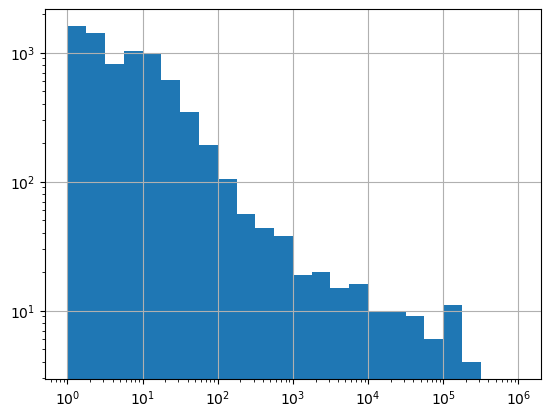

In [60]:
ax = pd.Series(members_df['PURPOSE'].value_counts().values).hist(bins=np.logspace(0,6,25))
ax.set_xscale('log')
ax.set_yscale('log')

In [753]:
members_df[members_df['PAYEE'].fillna('').str.contains('GRONEMAN')]

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
1701911,2015Q1,Z000017,HON. LEE M. ZELDIN,Q1,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2015-02-01,2015-03-31,CONGRESSIONAL AIDE,8583.34,2015,NaN,NaN,"GRONEMAN,BELINDA M",NaN,7
1798272,2015Q2,Z000017,HON. LEE M. ZELDIN,Q2,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2015-04-01,2015-06-30,CONGRESSIONAL AIDE,12875.01,2015,NaN,NaN,"GRONEMAN,BELINDA M",NaN,8
1798308,2015Q2,Z000017,HON. LEE M. ZELDIN,Q2,TRAVEL,2015-05-08,"GRONEMAN, BELINDA M",2015-04-12,2015-04-12,TRAVEL SUBSISTENCE,1984.75,2015,AP,E0276948,"GRONEMAN, BELINDA M",NaN,8
1798447,2015Q2,Z000017,HON. LEE M. ZELDIN,Q2,SUPPLIES AND MATERIALS,2015-06-30,"GRONEMAN, BELINDA M",2015-02-06,2015-02-06,FOOD & BEVERAGE,239.18,2015,AP,E0294888,"GRONEMAN, BELINDA M",NaN,8
1798448,2015Q2,Z000017,HON. LEE M. ZELDIN,Q2,SUPPLIES AND MATERIALS,2015-06-30,"GRONEMAN, BELINDA M",2015-03-12,2015-03-12,FOOD & BEVERAGE,156.81,2015,AP,E0294888,"GRONEMAN, BELINDA M",NaN,8
1889992,2015Q3,Z000017,HON. LEE M. ZELDIN,Q3,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2015-07-01,2015-09-30,CONGRESSIONAL AIDE,12875.01,2015,NaN,NaN,"GRONEMAN,BELINDA M",NaN,1
1985565,2015Q4,Z000017,HON. LEE M. ZELDIN,Q4,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2015-10-01,2015-12-31,CONGRESSIONAL AIDE,13635.01,2015,NaN,NaN,"GRONEMAN,BELINDA M",NaN,2
2087460,2016Q1,Z000017,HON. LEE M. ZELDIN,Q1,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2016-01-03,2016-03-31,CONGRESSIONAL AIDE,12588.90,2016,NaN,NaN,"GRONEMAN,BELINDA M",NaN,3
2087557,2016Q1,Z000017,HON. LEE M. ZELDIN,Q1,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2016-01-01,2016-01-02,CONGRESSIONAL AIDE,286.11,2016,NaN,NaN,"GRONEMAN,BELINDA M",NaN,3
2187774,2016Q2,Z000017,HON. LEE M. ZELDIN,Q2,PERSONNEL COMPENSATION,NaT,"GRONEMAN,BELINDA M",2016-04-01,2016-06-30,CONGRESSIONAL AIDE,12875.01,2016,NaN,NaN,"GRONEMAN,BELINDA M",NaN,4


In [752]:
members_df.loc[members_df['PAYEE'].fillna('').str.contains('GRONEMAN'),'PAYEE'].unique()

array(['GRONEMAN,BELINDA M', 'GRONEMAN, BELINDA M', 'GRONEMAN BELINDA M',
       'GRONEMAN BELINDA M.'], dtype=object)

## Relational anomalies

HC: More than one anomaly across tests, are there anomalies robust across types of tests?  
BK: Aides working for multiple offices in a single year?   
HC: Relationships within data + relationships among anomalies  

In [118]:
personnel_compensation_df

,YEAR-QUARTER,BIOGUIDE_ID,OFFICE,QUARTER,CATEGORY,DATE,PAYEE,START DATE,END DATE,PURPOSE,AMOUNT,YEAR,TRANSCODE,RECORDID,VOUCHER_ID,PROGRAM,TERM_QUARTER
6420,2011Q1,A000014,HON. NEIL ABERCROMBIE,Q1,PERSONNEL COMPENSATION,NaT,"WESTFALL, ERIN K",2009-09-01,2009-09-30,RESEARCH AND MEDIA ASSISTANT,-16.67,2011,NaN,NaN,"WESTFALL, ERIN K",NaN,7
6424,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,PERSONNEL COMPENSATION,NaT,"BERRY, UNA M",2011-01-03,2011-03-31,DISTRICT ADMINISTRATOR,19555.57,2011,NaN,NaN,"BERRY, UNA M",NaN,7
6425,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,PERSONNEL COMPENSATION,NaT,"CONNOLLY, BRENDA J",2011-01-03,2011-03-31,WASHINGTON SCHEDULER,14422.23,2011,NaN,NaN,"CONNOLLY, BRENDA J",NaN,7
6426,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,PERSONNEL COMPENSATION,NaT,"CRAMER,VANESSA L",2011-01-03,2011-03-10,LEGISLATIVE CORRESPONDENT,5666.67,2011,NaN,NaN,"CRAMER,VANESSA L",NaN,7
6427,2011Q1,A000022,HON. GARY L. ACKERMAN,Q1,PERSONNEL COMPENSATION,NaT,"DIAMOND, HOWARD",2011-01-03,2011-03-31,SHARED EMPLOYEE,8583.33,2011,NaN,NaN,"DIAMOND, HOWARD",NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4779438,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,PERSONNEL COMPENSATION,NaT,WOOLLEY MARK A,2022-10-01,2022-12-31,DISTRICT DIRECTOR,24999.99,2022,NaN,NaN,NaN,OFFICIAL EXPENSES OF MEMBERS,6
4779549,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,PERSONNEL COMPENSATION,NaT,KAMENEV LEON,2022-10-01,2022-12-01,PAID INTERN - HOUSE PROGRAM,2846.67,2022,NaN,NaN,NaN,INTERN ALLOWANCES,6
4779550,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,PERSONNEL COMPENSATION,NaT,ULRICH CAROLINE D.,2022-09-01,2022-09-30,PAID INTERN - HOUSE PROGRAM,-1500.00,2022,NaN,NaN,NaN,INTERN ALLOWANCES,6
4779551,2022Q4,Z000017,2022 HON. LEE M. ZELDIN,Q4,PERSONNEL COMPENSATION,NaT,VIOLA JULIANNE A.,2022-10-01,2022-12-16,DISTRICT OFFICE PAID INTERN -,3800.00,2022,NaN,NaN,NaN,INTERN ALLOWANCES,6


In [119]:
personnel_compensation_df = members_df[members_df['CATEGORY'] == 'PERSONNEL COMPENSATION']

annual_office_personnel_df = personnel_compensation_df.groupby(['YEAR','BIOGUIDE_ID','PAYEE']).agg({'AMOUNT':'sum'})
annual_office_personnel_df.reset_index(inplace=True)
annual_office_personnel_df.dropna(subset=['PAYEE'],inplace=True)
annual_office_personnel_df.head()

,YEAR,BIOGUIDE_ID,PAYEE,AMOUNT
0,2011,A000014,"WESTFALL, ERIN K",-16.67
1,2011,A000022,"BERRY, UNA M",80000.04
2,2011,A000022,"BRIANCON,ALICIA V",13124.98
3,2011,A000022,"CONNOLLY, BRENDA J",58705.59
4,2011,A000022,"CRAMER,VANESSA L",5833.33


Try to clean up PAYEE names.

In [219]:
yq_total_personnel = personnel_compensation_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID','PAYEE']).agg({'AMOUNT':'sum'})
yq_total_personnel.reset_index(inplace=True)
yq_total_personnel['PAYEE_CLEANED'] = np.nan

In [192]:
def name_reorganizer(s):
    _split_l = s.strip().split(' ')
    _len = len(_split_l)
    if _len == 1:
        return _split_l
    elif _len == 2:
        return _split_l[-1] + ' ' + _split_l[0]
    elif _len == 3:
        return _split_l[-2] + ' ' + _split_l[-1] + ' ' + _split_l[0]
    elif _len == 4:
        return _split_l[-2] + ' ' + _split_l[-1] + ' ' + _split_l[0] + ' ' + _split_l[1]
    elif _len == 5:
        return _split_l[-2] + ' ' + _split_l[-1] + ' ' + _split_l[0] + ' ' + _split_l[1] + ' ' + _split_l[2]

In [228]:
yq_total_personnel.loc[name_array_len_sep_comma[name_array_len_sep_comma != 2],:]

,YEAR-QUARTER,BIOGUIDE_ID,PAYEE,AMOUNT,PAYEE_CLEANED
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
3,2011Q1,A000022,"CRAMER,VANESSA L",5833.33,VANESSA L CRAMER
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
...,...,...,...,...,...
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY
1,2011Q1,A000022,"BERRY, UNA M",20000.01,UNA M BERRY


In [241]:
_s = yq_total_personnel.groupby('YEAR-QUARTER').agg({'PAYEE':lambda x:x.str.contains(',').sum()})['PAYEE']
comma_in_name_quarters = _s[_s > 0].index

# Filter to quarters where there are commas present
pre_2016Q4 = yq_total_personnel['YEAR-QUARTER'].isin(comma_in_name_quarters)

# Make a series that separates PAYEE on commas and counts the number of name elements -- ideally 2
name_array_len_sep_comma = yq_total_personnel.loc[pre_2016Q4,'PAYEE'].str.split(',').apply(len)

# Re-order names with exactly two name elements and additional cleanup
exactly_2 = name_array_len_sep_comma[name_array_len_sep_comma == 2]
pre_2016Q4_cleaned_names = yq_total_personnel.loc[exactly_2.index,'PAYEE'].str.split(',').apply(lambda x:x[1] + ' ' + x[0])
pre_2016Q4_cleaned_names = pre_2016Q4_cleaned_names.str.replace('  ', ' ').str.strip()

# Filter to quarters where there are no commas present
post_2016Q4 = ~yq_total_personnel['YEAR-QUARTER'].isin(comma_in_name_quarters)
post_2016Q4_cleaned_names = yq_total_personnel.loc[post_2016Q4,'PAYEE']
post_2016Q4_cleaned_names = post_2016Q4_cleaned_names.str.replace('  ', ' ').str.strip()
post_2016Q4_cleaned_names = post_2016Q4_cleaned_names.apply(name_reorganizer)

# Assign back to a new column
yq_total_personnel.loc[pre_2016Q4_cleaned_names.index,'PAYEE_CLEANED'] = pre_2016Q4_cleaned_names
yq_total_personnel.loc[post_2016Q4_cleaned_names.index,'PAYEE_CLEANED'] = post_2016Q4_cleaned_names

# Remove periods from names
yq_total_personnel.loc[:,'PAYEE_CLEANED'] = yq_total_personnel.loc[:,'PAYEE_CLEANED'].str.replace('.','').fillna('')
yq_total_personnel['PAYEE_CLEANED'] = yq_total_personnel['PAYEE_CLEANED'].replace({'T E ANFINSON':'THOMAS E ANFINSON'})

In [344]:
yq_total_personnel_filtered = yq_total_personnel[yq_total_personnel['AMOUNT'] >= 1000]

_agg = {'AMOUNT':'sum'}
personnel_el_df = yq_total_personnel_filtered.groupby(['YEAR-QUARTER','BIOGUIDE_ID','PAYEE_CLEANED']).agg(_agg)
# personnel_el_df.index.names = ['yearquarter','id','payee']
personnel_el_df.reset_index(inplace=True)
personnel_el_df['member'] = personnel_el_df['BIOGUIDE_ID'].map(member_names_map).str.upper()
personnel_el_df.columns = ['yearquarter','id','payee','amount','member']

personnel_el_df[['gender','party']] = personnel_el_df['id'].apply(lambda x:pd.Series(bioguide_gender_party_map.get(x)))
personnel_el_df.dropna(subset=['member'],inplace=True)

filtered_personnel_el = personnel_el_df[personnel_el_df['party'].isin(['D','R'])]

(41261, 52829)

In [ ]:
personnel_bp_g = nx.from_pandas_edgelist(
    df = filtered_personnel_el,
    source = 'member',
    target = 'payee',
    edge_attr = ['amount']
)

nx.write_gexf(personnel_bp_g,'personnel_bp.gexf')

personnel_bp_g.number_of_nodes(), personnel_bp_g.number_of_edges()

In [336]:
set(personnel_el_df['member']) & set(personnel_el_df['payee'])

{'KATIE HILL', 'PATRICK RYAN', 'RON WRIGHT'}

In [345]:
personnel_el_df[~personnel_el_df['party'].isin(['D','R','I'])]

,yearquarter,id,payee,amount,member,gender,party


In [347]:
personnel_attrs = filtered_personnel_el.groupby('payee').agg({'party':'unique','gender':'unique'})
personnel_attrs['party'] = personnel_attrs['party'].fillna('').apply(sorted).str.join(',')
personnel_attrs['gender'] = personnel_attrs['gender'].fillna('').apply(sorted).str.join(',')
personnel_attrs['joint'] = personnel_attrs['party'] + ',' + personnel_attrs['gender']

personnel_attrs['joint'].value_counts()

joint
R,M        16850
D,M        12404
D,F         6799
R,F         1942
D,F,M       1189
R,F,M        825
D,R,F,M      192
D,R,M        133
D,R,F         32
Name: count, dtype: int64

In [327]:
personnel_proj_g = nx.bipartite.projection.weighted_projected_graph(personnel_bp_g,filtered_personnel_el['payee'].unique())

joint_d = personnel_attrs['joint'].to_dict()
for node,d in personnel_proj_g.nodes(data=True):
    d['joint'] = joint_d.get(node,'')

nx.write_gexf(personnel_proj_g,'personnel_proj.gexf')

personnel_proj_g.number_of_nodes(), personnel_proj_g.number_of_edges()


(23061, 517616)

In [350]:
all_bio_payee_el_df = yq_total_personnel_filtered.groupby(['BIOGUIDE_ID','PAYEE_CLEANED']).agg({'AMOUNT':'sum'})
all_bio_payee_el_df.reset_index(inplace=True)
all_bio_payee_el_df.columns = ['id','payee','amount']

all_bio_payee_el_df['payee'].value_counts().head(20)

payee
KRYSTAL C KAAI           99
MICHAEL P DARNER         90
BRADLEY M BAUMAN         80
MARIA L LAVERDIERE       76
JOHN D GROM              75
GABRIELLE K GOULD        69
THOMAS E ANFINSON        60
JUSTIN S OUIMETTE        52
ADAM J PASE              52
KATE OSTRANDER           52
SUSAN ANFINSON           51
MATTHEW DICKERSON        50
MATTHEW S WEINER         48
PAUL S TELLER            47
CURTIS E RHYNE           47
CHRISTOPHER D STEVENS    46
REBEKAH W ARMSTRONG      46
WILL DUNHAM              45
MARTIN RADOSEVICH        44
SHANNA E FRICKLAS        44
Name: count, dtype: int64

In [360]:
_df

1431     24000.01
11405    17000.01
19969    17000.01
20026     1180.56
21217     1633.50
           ...   
349976    6000.00
351673    1000.00
353103    1000.00
353661    6000.00
354104    6000.00
Name: AMOUNT, Length: 843, dtype: float64

In [368]:
top_payees = ['KRYSTAL C KAAI','MICHAEL P DARNER','BRADLEY M BAUMAN','MARIA L LAVERDIERE', 'JOHN D GROM']
_df = yq_total_personnel_filtered.loc[yq_total_personnel_filtered['PAYEE_CLEANED'].isin(top_payees),:]

pd.pivot_table(
    data = _df,
    index = 'YEAR-QUARTER',
    columns = 'PAYEE_CLEANED',
    values = 'AMOUNT',
    aggfunc = 'sum'
).describe()

PAYEE_CLEANED,BRADLEY M BAUMAN,JOHN D GROM,KRYSTAL C KAAI,MARIA L LAVERDIERE,MICHAEL P DARNER
count,10.00,19.00,40.00,27.00,33.00
mean,24693.76,28023.88,18123.80,14757.84,26145.96
std,6516.05,7413.83,6806.63,6338.87,6496.15
min,15681.60,4937.50,5733.67,4000.00,17000.01
25%,21706.11,29311.33,14392.91,10636.98,20874.99
50%,23505.80,29625.00,17424.16,15875.00,25000.00
75%,26899.99,31467.12,21370.84,19325.00,30000.00
max,39334.24,35000.00,33500.93,25450.00,38000.00


In [369]:
all_bio_payee_el_df['payee'].value_counts()

payee
KRYSTAL C KAAI         99
MICHAEL P DARNER       90
BRADLEY M BAUMAN       80
MARIA L LAVERDIERE     76
JOHN D GROM            75
                       ..
DANIEL R CANNIFF        1
CAITLIN A SHUBICK       1
BRIAN F DOBSON          1
ASHLEY M PRATTE         1
ZACHARIAH J GAMBILL     1
Name: count, Length: 40587, dtype: int64

What's up with the Anfinsons?

In [349]:
_df = yq_total_personnel[yq_total_personnel['PAYEE_CLEANED'].str.contains('ANFINSON')]

pd.pivot_table(
    data = _df,
    index = 'YEAR-QUARTER',
    columns = 'PAYEE_CLEANED',
    values = 'BIOGUIDE_ID',
    aggfunc = 'nunique'
)

PAYEE_CLEANED,ASHLEY M ANFINSON,SUSAN ANFINSON,THOMAS E ANFINSON
YEAR-QUARTER,,,
2011Q1,NaN,36.00,38.00
2011Q2,NaN,28.00,32.00
2011Q3,NaN,28.00,33.00
2011Q4,NaN,30.00,32.00
2012Q1,NaN,30.00,31.00
2012Q2,NaN,30.00,31.00
2012Q3,NaN,30.00,30.00
2012Q4,NaN,30.00,33.00
2013Q1,NaN,29.00,30.00


In [248]:
pd.pivot_table(
    data = _df,
    index = 'YEAR-QUARTER',
    columns = 'PAYEE_CLEANED',
    values = 'AMOUNT',
    aggfunc = 'sum'
)

PAYEE_CLEANED,ASHLEY M ANFINSON,SUSAN ANFINSON,THOMAS E ANFINSON
YEAR-QUARTER,,,
2011Q1,NaN,42102.75,84205.52
2011Q2,NaN,42102.75,84205.50
2011Q3,NaN,42102.75,84205.50
2011Q4,NaN,42102.75,84205.50
2012Q1,NaN,42102.75,84205.50
2012Q2,NaN,42102.75,84205.50
2012Q3,NaN,42102.75,84205.50
2012Q4,NaN,42102.75,84205.50
2013Q1,NaN,42102.75,80104.58


In [180]:
space_count = yq_total_personnel.loc[:,'PAYEE'].str.split(' ').apply(len)
yq_total_personnel.loc[space_count == 6,'PAYEE_CLEANED']

In [188]:
post_2016Q4_cleaned_names

192507     ABERNATHY PAMELA M.
192508          CLARK CARSON G
192509          DAWSON MARK E.
192510     DONCHES MICHELLE M.
192511      GROOVER JENNIFER E
                  ...         
412853      ULRICH CAROLINE D.
412854    VINCENTZ KATHLEEN C.
412855       VIOLA JULIANNE A.
412856            WITMAN COLIN
412857          WOOLLEY MARK A
Name: PAYEE, Length: 220351, dtype: object

In [197]:
yq_total_personnel.loc[~yq_total_personnel['YEAR-QUARTER'].isin(comma_in_name_quarters),'PAYEE'].apply(name_reorganizer)

192507     PAMELA M. ABERNATHY
192508          CARSON G CLARK
192509          MARK E. DAWSON
192510     MICHELLE M. DONCHES
192511      JENNIFER E GROOVER
                  ...         
412853      CAROLINE D. ULRICH
412854    KATHLEEN C. VINCENTZ
412855       JULIANNE A. VIOLA
412856            COLIN WITMAN
412857          MARK A WOOLLEY
Name: PAYEE, Length: 220351, dtype: object

193997    DE LOS SANTOS FLORES BABUR I
Name: PAYEE_CLEANED, dtype: object

In [187]:
yq_total_personnel.loc[yq_total_personnel['PAYEE'].str.contains('FALKOWSKI'),'YEAR-QUARTER'].values

array(['2013Q1', '2013Q2', '2013Q3', '2013Q4', '2014Q1', '2014Q2',
       '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3', '2015Q4',
       '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2',
       '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4',
       '2019Q1', '2022Q4'], dtype=object)

In [170]:
yq_total_personnel['PAYEE_CLEANED'].value_counts()

PAYEE_CLEANED
SUSAN ANFINSON           640
THOMAS E ANFINSON        593
T E ANFINSON             533
ANFINSON SUSAN           462
DOHERTY KATHRYN J.       426
                        ... 
RAGAN CALEB I.             1
RAMOS HECTOR A             1
BAILEY JARED M             1
HILL JASMINE K             1
FALKOWSKI BENJAMIN E.      1
Name: count, Length: 54247, dtype: int64

In [139]:
annual_personnel_to_2016 = annual_office_personnel_df.loc[annual_office_personnel_df['YEAR'] <= 2015,:]
annual_personnel_to_2016[annual_personnel_to_2016.loc[:,'PAYEE'].str.split(',').apply(len) == 1]

#


,YEAR,BIOGUIDE_ID,PAYEE,AMOUNT
363,2011,B000213,KRISTA C. ROSENTHALL,3343.75
1007,2011,B001243,SEAN MCLEAN,51833.35
2598,2011,C001077,MILLER RIVERA-ANNICK M,17616.67
2843,2011,D000096,CLAYTON C BOYD,26528.61
2850,2011,D000096,JOSEPH PETERS,35700.00
3565,2011,E000215,VENDOR NOT FOUND - PAY161800,13562.50
3994,2011,F000453,BENNETT KALEB,1000.00
6085,2011,J000285,WILLIAM A KYLES II,18000.20
7163,2011,L000568,KELLY PATRICK M. JR,3219.45
9304,2011,P000592,KIMBERLY A BRODE,53250.04


In [149]:
annual_office_personnel_df[annual_office_personnel_df['PAYEE'].str.contains('VENDOR')]

,YEAR,BIOGUIDE_ID,PAYEE,AMOUNT
3565,2011,E000215,VENDOR NOT FOUND - PAY161800,13562.50
16731,2012,G000553,VENDOR NOT FOUND - PAY164455,2666.67
41474,2014,M001165,VENDOR NOT FOUND - PAY167922,750.00
124374,2021,C000537,VENDOR NOT FOUND - PAY193606,1033.33
126562,2021,E000297,VENDOR NOT FOUND - PAY193106,1166.67
139121,2022,C000537,VENDOR NOT FOUND - PAY195424,262.50
148739,2022,R000575,VENDOR NOT FOUND - PAY197883,2031.94


## Other data sources

HC: Spending based on ethical rhetoric on social media, public statements, legislation sponsored  
HC: George Santos! Let's look at his spending  
HC: Use House Ethics history to flag members who have previously been subject of an investigation